# Telco Customer Churn — Predictive Modeling (Step 12-18)

Notebook นี้ต่อจาก **`telco_churn_eda.ipynb`** (Step 1-11: Data Cleaning + EDA) เพื่อสร้างโมเดล Machine Learning ที่ทำนาย Churn
และเปรียบเทียบ feature importance กับ insight เชิงสถิติที่เจอใน EDA

**ก่อนรัน notebook นี้:** ต้องรัน `telco_churn_eda.ipynb` ให้จบก่อนอย่างน้อย 1 ครั้ง เพื่อสร้างไฟล์ `data/telco_churn_clean.csv`
ที่ notebook นี้จะโหลดมาใช้ต่อ


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Tahoma'  # รองรับข้อความภาษาไทยในกราฟ (เหตุผลเดียวกับที่อธิบายไว้ใน Step 3 ของ EDA notebook)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# โหลดข้อมูลที่ clean แล้วจาก telco_churn_eda.ipynb กลับมา (index_col='customerID' เพราะตอนเซฟไว้ ใช้ customerID เป็น index)
df = pd.read_csv('../data/processed/telco_churn_clean.csv', index_col='customerID')

print(f"โหลดข้อมูลสำเร็จ: {df.shape[0]} แถว x {df.shape[1]} คอลัมน์")
df.head()

โหลดข้อมูลสำเร็จ: 7032 แถว x 21 คอลัมน์


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48
3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48
9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12


**สิ่งที่โหลดมาได้:** dataframe ที่ผ่านการ clean แล้วจาก EDA notebook ครบทุกจุด (`TotalCharges` เป็นตัวเลข, ไม่มี 11 แถวที่
tenure=0, `SeniorCitizen` เป็น Yes/No) รวมถึงคอลัมน์ `tenure_bucket` ที่สร้างไว้ใน Step 8 (จะไม่ถูกใช้ในโมเดล เพราะซ้ำซ้อนกับ `tenure`)

ต่อไปนี้คือ Step 12 ที่ย้ายมาจาก `telco_churn_eda.ipynb` (feature engineering & encoding) แล้วต่อด้วย Step 13-18


In [2]:
# กำหนดรายชื่อคอลัมน์ categorical และ numeric ใหม่ (เหมือนกับที่นิยามไว้ใน Step 4 ของ EDA notebook)
# จำเป็นต้องนิยามใหม่ในไฟล์นี้ เพราะตัวแปรในหน่วยความจำ (memory) ของ notebook คนละไฟล์ไม่เชื่อมถึงกัน มีแค่ไฟล์ CSV ที่ส่งต่อข้อมูลจริงๆ เท่านั้น
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                     'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# ส่วนที่ 2: Predictive Modeling (Step 12-18)

Step 1-11 ที่ผ่านมาเป็นการสำรวจข้อมูล (EDA) ล้วนๆ ตอนนี้จะเริ่มสร้าง **โมเดล Machine Learning** เพื่อทำนายว่าลูกค้าคนไหนจะ churn
และดูว่าปัจจัยไหนมีน้ำหนักมากที่สุดในการทำนาย (feature importance) เทียบกับ insight เชิงสถิติที่เจอใน EDA ว่าตรงกันหรือไม่

## Step 12: Feature Engineering & Encoding for ML (เตรียมข้อมูลให้พร้อมสำหรับโมเดล)

**จะทำอะไร:** โมเดล Machine Learning ทุกชนิดรับ input เป็น **ตัวเลขเท่านั้น** ไม่สามารถเข้าใจข้อความอย่าง "Yes"/"No" หรือ "Month-to-month"
ได้โดยตรง Step นี้จึงต้องแปลงข้อมูลทั้งหมดให้เป็นตัวเลข แล้วแบ่งเป็นชุด train/test ก่อนเริ่มเทรนโมเดลใน Step 14-15 แบ่งเป็น 4 ขั้นตอนย่อย:
(12.1) เข้ารหัส target (12.2) เข้ารหัส categorical features (12.3) แบ่ง train/test (12.4) ปรับสเกลตัวเลข


### 12.1 เข้ารหัส Target Variable

**จะทำอะไร:** แปลงคอลัมน์ `Churn` จากข้อความ "Yes"/"No" ให้เป็นตัวเลข 1/0 (1 = churn, 0 = ไม่ churn)

**ทำไมต้องทำ:** โมเดล classification ของ scikit-learn ต้องการให้ target เป็นตัวเลข (หรืออย่างน้อยต้องเข้ารหัสภายในเป็นตัวเลขอยู่ดี)
การแปลงเองไว้ล่วงหน้าทำให้ควบคุมได้ชัดเจนว่า 1 หมายถึงอะไร (สะดวกตอนอ่านผลลัพธ์ทีหลัง เช่น ความน่าจะเป็นที่โมเดลทำนายจะหมายถึง "โอกาส churn")


In [3]:
# (df['Churn'] == 'Yes') สร้าง Series ของค่า True/False ทีละแถว ตามว่าแถวนั้น Churn เป็น Yes หรือไม่
# .astype(int) แปลง True/False ให้เป็นตัวเลข 1/0 (True กลายเป็น 1, False กลายเป็น 0)
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

df[['Churn', 'Churn_numeric']].head()

,Churn,Churn_numeric
customerID,,
7590-VHVEG,No,0
5575-GNVDE,No,0
3668-QPYBK,Yes,1
7795-CFOCW,No,0
9237-HQITU,Yes,1


**ผลลัพธ์หมายความว่าอย่างไร:** ตอนนี้มีคอลัมน์ `Churn_numeric` เพิ่มขึ้นมา ซึ่งเป็นตัวเลข 1/0 ที่มีความหมายตรงกับ `Churn` เดิมทุกประการ
(Yes → 1, No → 0) พร้อมนำไปใช้เป็น target ของโมเดลในขั้นตอนถัดไป


### 12.2 One-Hot Encoding สำหรับ Categorical Features

**จะทำอะไร:** แปลงตัวแปรหมวดหมู่ทั้ง 16 คอลัมน์ (ตัวแปรเดียวกับที่ใช้ใน Step 4-5) ให้เป็นตัวเลขด้วยเทคนิคที่เรียกว่า **One-Hot Encoding**

**One-Hot Encoding คืออะไร (แบบเข้าใจง่าย):** สมมติคอลัมน์ `Contract` มี 3 ค่า (Month-to-month, One year, Two year) One-Hot Encoding
จะสร้างคอลัมน์ใหม่แยกกัน 1 คอลัมน์ต่อ 1 ค่า เช่น `Contract_One year` (มีค่า 1 ถ้าลูกค้าคนนั้นทำสัญญา 1 ปี, มีค่า 0 ถ้าไม่ใช่) และ
`Contract_Two year` (เหมือนกัน) — เปรียบเหมือนตั้งคำถามใช่/ไม่ใช่แยกกันสำหรับแต่ละตัวเลือก แทนที่จะเก็บเป็นข้อความเดียว

**ทำไมต้องใช้ `drop_first=True`:** ถ้าเรารู้ว่าลูกค้าไม่ใช่ Month-to-month และไม่ใช่ One year ก็สรุปได้เองว่าต้องเป็น Two year แน่นอน
(ไม่ต้องมีคอลัมน์ `Contract_Two year` ก็รู้คำตอบได้) การเก็บครบทุกค่าจะทำให้เกิดปัญหาที่เรียกว่า **dummy variable trap** — คอลัมน์ต่างๆ
ทำนายกันเองได้แบบสมบูรณ์ (perfect multicollinearity) ซึ่งจะทำให้ผลลัพธ์ของ Logistic Regression ใน Step 14 ตีความยากขึ้น การใส่
`drop_first=True` จะตัดค่าตัวแรกออกไป 1 ค่าเสมอ (เหลือไว้เป็นค่า "ฐาน" หรือ baseline ให้เทียบ) แก้ปัญหานี้ได้


In [4]:
# pd.get_dummies() คือฟังก์ชันสำเร็จรูปของ pandas สำหรับทำ One-Hot Encoding
# ใส่เฉพาะคอลัมน์ categorical_cols (16 ตัวจาก Step 4) ไม่รวมตัวเลขหรือ target
# drop_first=True ตัดค่าตัวแรกของแต่ละคอลัมน์ออก 1 ค่าเสมอ ตามเหตุผลที่อธิบายไว้ข้างบน
# .astype(int) แปลงคอลัมน์ dummy จาก bool (True/False) ให้เป็นตัวเลข 0/1 อย่างชัดเจน
# จำเป็นมาก เพราะ pandas เวอร์ชันใหม่ทำให้ pd.get_dummies คืนค่าเป็น bool แทน 0/1 ตัวเลขปกติ
# ถ้าปล่อยเป็น bool ปนกับคอลัมน์ float ในตารางเดียวกัน ตอนแปลงเป็น array ให้ scikit-learn ใช้งาน
# จะกลายเป็น dtype แบบ 'object' (ไม่ใช่ตัวเลขล้วน) ซึ่งทำให้การคำนวณข้างในโมเดล (เช่น Logistic Regression ใน Step 14)
# ทำงานผิดพลาดแบบเงียบๆ (เกิด overflow warning ระหว่างเทรน) — .astype(int) ป้องกันปัญหานี้ตั้งแต่ต้นทาง
X_categorical = pd.get_dummies(df[categorical_cols], drop_first=True).astype(int)

print(f"จำนวนคอลัมน์ก่อนเข้ารหัส: {len(categorical_cols)}")
print(f"จำนวนคอลัมน์หลังเข้ารหัส (One-Hot): {X_categorical.shape[1]}")
X_categorical.head()

จำนวนคอลัมน์ก่อนเข้ารหัส: 16
จำนวนคอลัมน์หลังเข้ารหัส (One-Hot): 27


,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
5575-GNVDE,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
3668-QPYBK,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
7795-CFOCW,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
9237-HQITU,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


**ผลลัพธ์หมายความว่าอย่างไร:** จาก 16 คอลัมน์เดิม กลายเป็นคอลัมน์ตัวเลขจำนวนมากขึ้น (เพราะบางคอลัมน์เช่น `InternetService`,
`PaymentMethod` มีมากกว่า 2 ค่า จึงถูกแตกเป็นหลายคอลัมน์) แต่ละคอลัมน์ใหม่มีค่าแค่ 0 หรือ 1 เท่านั้น (คอลัมน์แบบนี้เรียกว่า dummy variable)
พร้อมนำไปใช้เป็น input ของโมเดลได้แล้ว


In [5]:
# รวมคอลัมน์ตัวเลขเดิม (numeric_cols จาก Step 4) เข้ากับคอลัมน์ dummy ที่เพิ่งสร้าง ให้เป็นตาราง feature เดียว (X)
# pd.concat([...], axis=1) แปลว่า "เอาตารางมาต่อกันตามแนวคอลัมน์" (axis=1 คือต่อข้าง ต่างจาก axis=0 ที่ต่อแถว)
X = pd.concat([df[numeric_cols], X_categorical], axis=1)

# y คือ target ที่จะให้โมเดลทำนาย (ค่าที่เพิ่งเข้ารหัสไว้ใน 12.1)
y = df['Churn_numeric']

print(f"Feature matrix X: {X.shape[0]} แถว x {X.shape[1]} คอลัมน์")
print(f"Target y: {y.shape[0]} แถว")

Feature matrix X: 7032 แถว x 30 คอลัมน์
Target y: 7032 แถว


**หมายเหตุ:** ตัวแปร `tenure_bucket` ที่สร้างไว้ใน Step 8 (สำหรับทำตารางไขว้) **ไม่ถูกนำมาใส่ใน X** เพราะมันเป็นแค่การแบ่งช่วงของ
`tenure` ที่มีอยู่แล้ว การใส่ทั้งสองตัวพร้อมกันจะทำให้เกิดข้อมูลซ้ำซ้อน (redundant) โดยไม่ได้ประโยชน์เพิ่ม


### 12.3 แบ่งข้อมูลเป็น Train/Test Set

**จะทำอะไร:** แบ่งลูกค้าทั้งหมดออกเป็น 2 กลุ่มแบบสุ่ม — **80% สำหรับ "สอน" โมเดล (training set)** และ **20% สำหรับ "สอบ" โมเดล
(test set)** โดยที่โมเดลจะไม่เคยเห็นข้อมูลใน test set เลยระหว่างเทรน

**ทำไมต้องแบ่ง:** ถ้าเอาข้อมูลเดียวกันมาทั้งสอนและสอบ โมเดลอาจแค่ "จำ" คำตอบได้หมดโดยไม่ได้เรียนรู้ pattern ที่ใช้ได้จริง (ปัญหานี้เรียกว่า
**overfitting**) การแบ่งข้อมูลที่โมเดลไม่เคยเห็นมาทดสอบ จะบอกได้ว่าโมเดลเก่งจริงหรือแค่จำข้อสอบมา

**ทำไมต้องใช้ `stratify=y`:** จาก Step 3 เรารู้ว่าข้อมูลไม่สมดุล (churn แค่ 26.6%) ถ้าแบ่งแบบสุ่มธรรมดา อาจบังเอิญได้ train set ที่มี
สัดส่วน churn ต่างจาก test set มาก (เช่น train มี churn 30% แต่ test มีแค่ 20%) ทำให้เปรียบเทียบผลลัพธ์ได้ไม่แม่นยำ `stratify=y`
บังคับให้สัดส่วน churn ใน train และ test ใกล้เคียงกับสัดส่วนจริง (26.6%) ทั้งคู่


In [6]:
from sklearn.model_selection import train_test_split

# test_size=0.2 แปลว่าแบ่งไป test set 20% (เหลือ train 80%)
# stratify=y บังคับให้สัดส่วนของ y (churn/ไม่ churn) เท่ากันทั้งใน train และ test
# random_state=42 ล็อกการสุ่มให้ได้ผลลัพธ์เดิมทุกครั้งที่รัน (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape[0]} แถว ({y_train.mean() * 100:.1f}% churn)")
print(f"Test set: {X_test.shape[0]} แถว ({y_test.mean() * 100:.1f}% churn)")

Train set: 5625 แถว (26.6% churn)
Test set: 1407 แถว (26.6% churn)


**ผลลัพธ์หมายความว่าอย่างไร:** ยืนยันว่า `stratify=y` ทำงานถูกต้อง — สัดส่วน churn ใน train set และ test set ใกล้เคียงกับ
base rate 26.6% ทั้งคู่ (ต่างกันเพียงเศษเสี้ยว % เพราะการปัดเศษจากการแบ่งเป็นจำนวนเต็มคน) พร้อมนำไปเทรนโมเดลใน Step 14-15


### 12.4 ปรับสเกลตัวเลข (Feature Scaling)

**จะทำอะไร:** ปรับค่าตัวเลข 3 คอลัมน์ (`tenure`, `MonthlyCharges`, `TotalCharges`) ให้อยู่ใน**สเกลเดียวกัน** โดยใช้เทคนิคที่ชื่อ
**StandardScaler** ซึ่งจะแปลงแต่ละค่าให้มีค่าเฉลี่ย (mean) เป็น 0 และส่วนเบี่ยงเบนมาตรฐาน (std) เป็น 1

**ทำไมต้อง scale:** สังเกตจาก Step 4 ว่า `tenure` มีค่าตั้งแต่ 1-72 ในขณะที่ `TotalCharges` มีค่าตั้งแต่ ~19 ถึง ~8,700 — ถ้าไม่ปรับสเกล
โมเดลอย่าง Logistic Regression (Step 14) ที่คำนวณระยะห่าง/น้ำหนักตามขนาดตัวเลข จะให้ "น้ำหนัก" กับ `TotalCharges` มากเกินจริงเพียงเพราะ
ตัวเลขมันใหญ่กว่า ทั้งที่ไม่ได้เกี่ยวข้องกับ Churn มากกว่าจริง การ scale ให้ทุกคอลัมน์อยู่ในขนาดใกล้เคียงกันจะทำให้เปรียบเทียบน้ำหนัก
ความสำคัญของแต่ละตัวแปรได้อย่างเป็นธรรม (Random Forest ใน Step 15 ไม่จำเป็นต้อง scale แต่ scale ไว้ก็ไม่ทำให้ผลลัพธ์แย่ลง)

**ทำไมต้อง fit บน train set เท่านั้น:** `StandardScaler` ต้องคำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานมาก่อนถึงจะปรับสเกลได้ ถ้าคำนวณค่าเฉลี่ย
จากข้อมูลทั้งหมด (รวม test set ด้วย) จะเท่ากับให้โมเดล "แอบเห็น" ข้อมูลของ test set ตั้งแต่ก่อนเทรน (เรียกว่า **data leakage**)
ซึ่งจะทำให้ผลการทดสอบดูดีเกินจริงกว่าที่ควรจะเป็นจริงเมื่อเอาไปใช้กับข้อมูลใหม่ในโลกจริง


In [7]:
from sklearn.preprocessing import StandardScaler

# .copy() ป้องกัน warning ของ pandas เวลาจะแก้ไขค่าในตารางที่ตัดมาจากตารางใหญ่กว่า (X)
X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()

# .fit_transform() บน train: คำนวณค่าเฉลี่ย/std จาก train set (fit) แล้วปรับสเกลค่าของ train set เลยในขั้นตอนเดียว (transform)
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# .transform() บน test: ใช้ค่าเฉลี่ย/std ที่ "จำ" ไว้จาก train set มาปรับสเกล test set (ไม่คำนวณค่าเฉลี่ยใหม่จาก test)
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("ค่าเฉลี่ยของตัวเลขใน train set หลัง scale (ควรใกล้ 0 มาก):")
print(X_train[numeric_cols].mean().round(3))

ค่าเฉลี่ยของตัวเลขใน train set หลัง scale (ควรใกล้ 0 มาก):
tenure           -0.0
MonthlyCharges    0.0
TotalCharges      0.0
dtype: float64


**ผลลัพธ์หมายความว่าอย่างไร:** ค่าเฉลี่ยของทั้ง 3 คอลัมน์ใน train set หลัง scale ใกล้เคียง 0 มาก (เป็นไปตามหลักการของ
StandardScaler) ยืนยันว่าการปรับสเกลทำงานถูกต้อง ส่วน test set จะไม่ได้มีค่าเฉลี่ยเป๊ะ 0 (เพราะ scale ด้วยค่าเฉลี่ยของ train ไม่ใช่ของตัวเอง)
ซึ่งเป็นเรื่องปกติและเป็นสิ่งที่ต้องการ — ป้องกัน data leakage ตามที่อธิบายไว้ข้างบน


**สรุป Step 12:** เตรียมข้อมูลพร้อมสำหรับโมเดลแล้วครบทุกขั้นตอน — เข้ารหัส target เป็น 0/1, แปลง categorical เป็น dummy variables
ด้วย One-Hot Encoding, แบ่ง train (80%) / test (20%) แบบรักษาสัดส่วน churn ไว้เท่ากัน, และปรับสเกลตัวเลขโดยไม่ให้เกิด data leakage

ขั้นตอนถัดไป (Step 13) จะแก้ปัญหาข้อมูล imbalanced ด้วย SMOTE ก่อนนำไปเทรนโมเดลจริงใน Step 14-15


## Step 13: Handle Class Imbalance ด้วย SMOTE (แก้ปัญหาข้อมูลไม่สมดุล)

**จะทำอะไร:** จาก Step 3 เรารู้ว่าลูกค้าที่ churn มีแค่ 26.6% ของทั้งหมด (เทียบกับ 73.4% ที่ไม่ churn) — ข้อมูลแบบนี้เรียกว่า
**imbalanced data** (ข้อมูลไม่สมดุล) Step นี้จะใช้เทคนิคที่ชื่อ **SMOTE** เพิ่มตัวอย่างของกลุ่ม churn=Yes ใน **training set เท่านั้น**
ให้มีจำนวนเท่ากับกลุ่ม churn=No ก่อนนำไปเทรนโมเดลใน Step 14-15

**ทำไมข้อมูลไม่สมดุลถึงเป็นปัญหา:** ลองนึกภาพให้โมเดลท่องจำแบบขี้เกียจที่สุด — ถ้าโมเดลทายว่า **"ลูกค้าทุกคนไม่ churn"** ตลอดเวลา
โดยไม่ต้องเรียนรู้อะไรเลย ก็จะได้ความแม่นยำ (accuracy) สูงถึง ~73.4% ทันที เพราะกลุ่มใหญ่ของข้อมูลคือคนที่ไม่ churn อยู่แล้ว โมเดลที่เทรนบน
ข้อมูลไม่สมดุลจึงมักจะ "เอนเอียง" ไปทายกลุ่มใหญ่เป็นหลักและมองข้ามกลุ่ม churn ซึ่งเป็นกลุ่มที่ธุรกิจสนใจที่สุด (การหาลูกค้าที่จะเลิกใช้บริการ
ให้เจอ สำคัญกว่าการทายถูกว่าใครจะอยู่ต่อ)

**SMOTE ทำงานอย่างไร (แบบเข้าใจง่าย):** SMOTE ย่อมาจาก Synthetic Minority Over-sampling Technique — แทนที่จะ copy ข้อมูลกลุ่มน้อย
(churn=Yes) ซ้ำๆ ตรงๆ (ซึ่งจะทำให้โมเดลแค่ "จำ" ตัวอย่างเดิมซ้ำ ไม่ได้เรียนรู้อะไรใหม่) SMOTE จะ **สร้างตัวอย่างสังเคราะห์ใหม่**
โดยดูลูกค้ากลุ่ม churn ที่มีอยู่จริง 2 คนที่คล้ายกัน แล้ว "สุ่มจุดระหว่างกลาง" ของทั้งคู่ขึ้นมาเป็นลูกค้าสมมติคนใหม่ ทำแบบนี้ซ้ำๆ
จนกลุ่ม churn มีจำนวนเท่ากับกลุ่มไม่ churn

**ทำไมต้องทำกับ train set เท่านั้น ห้ามทำกับ test set:** test set มีหน้าที่จำลอง "โลกจริง" เพื่อวัดว่าโมเดลจะทำงานได้ดีแค่ไหนเมื่อเจอ
ลูกค้าจริงในอนาคต ถ้าไปทำ SMOTE กับ test set ด้วย จะทำให้สัดส่วน churn ใน test set ผิดเพี้ยนไปจากความเป็นจริง (กลายเป็น 50/50 ทั้งที่จริง
ควรจะเป็น 26.6/73.4) การวัดผลใน Step 16 จะไม่สะท้อนประสิทธิภาพจริงของโมเดลอีกต่อไป


In [8]:
from imblearn.over_sampling import SMOTE

# ปิด warning ที่ไม่เกี่ยวข้อง (imbalanced-learn เรียกใช้ฟังก์ชันภายในของ sklearn ที่ถูก deprecate ไปแล้ว
# เป็นแค่ปัญหาความเข้ากันได้ระหว่างเวอร์ชัน library ไม่ใช่ปัญหาของโค้ดหรือผลลัพธ์)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# แสดงจำนวนตัวอย่างของแต่ละ class ใน training set ก่อนทำ SMOTE (0 = ไม่ churn, 1 = churn)
print("ก่อนทำ SMOTE (train set):")
print(y_train.value_counts())

# random_state=42 ล็อกการสุ่มให้ได้ผลลัพธ์เดิมทุกครั้งที่รัน (เหมือนที่ใช้ตลอดทั้งโปรเจกต์)
smote = SMOTE(random_state=42)

# .fit_resample() เรียนรู้การกระจายตัวของข้อมูล (fit) แล้วสร้างตัวอย่างสังเคราะห์เพิ่มจนสองกลุ่มเท่ากัน (resample)
# ใช้เฉพาะกับ X_train, y_train เท่านั้น — ห้ามยุ่งกับ X_test, y_test เด็ดขาด
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nหลังทำ SMOTE (train set):")
print(y_train_smote.value_counts())

ก่อนทำ SMOTE (train set):
Churn_numeric
0    4130
1    1495
Name: count, dtype: int64

หลังทำ SMOTE (train set):
Churn_numeric
0    4130
1    4130
Name: count, dtype: int64


**ผลลัพธ์หมายความว่าอย่างไร:** ก่อนทำ SMOTE, training set มีลูกค้าไม่ churn (0) กับ churn (1) ในสัดส่วนไม่เท่ากันตามธรรมชาติของข้อมูล
(ประมาณ 73:27) หลังทำ SMOTE จำนวนของทั้งสองกลุ่มเท่ากันพอดี — แถวที่เพิ่มขึ้นมาทั้งหมดเป็นลูกค้า **"สังเคราะห์"** (synthetic) ของกลุ่ม
churn=Yes ที่ SMOTE สร้างขึ้นจากรูปแบบของลูกค้า churn จริงที่มีอยู่ ไม่ใช่ลูกค้าจริงเพิ่มขึ้นมา

**สิ่งสำคัญที่ต้องจำ:** `X_test`/`y_test` **ไม่ถูกแตะต้องเลย** ยังคงสัดส่วน churn ตามความเป็นจริง (26.6%) ไว้เหมือนเดิม — `X_train_smote`/
`y_train_smote` เท่านั้นที่จะถูกนำไปใช้เทรนโมเดลใน Step 14-15 ส่วนการวัดผลใน Step 16 จะใช้ `X_test`/`y_test` ชุดเดิมเสมอ

**สรุป Step 13:** แก้ปัญหาข้อมูลไม่สมดุลด้วย SMOTE เรียบร้อยแล้ว — training set มีตัวอย่างของทั้งสองกลุ่มเท่ากัน พร้อมให้โมเดลเรียนรู้
pattern ของกลุ่ม churn ได้อย่างเต็มที่ โดยที่ test set ยังคงสะท้อนสัดส่วนจริงของโลกจริงไว้สำหรับการประเมินผลอย่างเป็นธรรมใน Step 16

ขั้นตอนถัดไป (Step 14) จะเริ่มเทรนโมเดลแรก: Logistic Regression


## Step 14: Train Model 1 — Logistic Regression (เทรนโมเดลแรก)

**จะทำอะไร:** เทรนโมเดล **Logistic Regression** บนข้อมูล train ที่ทำ SMOTE แล้วจาก Step 13 แล้วใช้โมเดลทำนายผลบน test set
(การประเมินผลอย่างละเอียดจะไปทำใน Step 16 — ตอนนี้แค่เทรนและดูผลทำนายเบื้องต้น)

**Logistic Regression คืออะไร (แบบเข้าใจง่าย):** เป็นโมเดลที่หา "เส้นแบ่ง" ระหว่างกลุ่ม churn กับไม่ churn โดยให้น้ำหนัก (coefficient)
กับแต่ละ feature ว่ามีผลต่อโอกาส churn มากน้อยแค่ไหนและไปในทิศทางไหน (เพิ่มหรือลดโอกาส) แล้วรวมน้ำหนักทั้งหมดคำนวณออกมาเป็น
**ความน่าจะเป็น** (probability) ระหว่าง 0 ถึง 1 ว่าลูกค้าคนนั้นจะ churn — ถ้าความน่าจะเป็นมากกว่า 0.5 โมเดลจะสรุปว่า "churn"
ถ้าน้อยกว่าจะสรุปว่า "ไม่ churn"

**ทำไมเลือกโมเดลนี้เป็นตัวแรก:** Logistic Regression **ตีความง่ายที่สุด** ในบรรดาโมเดล classification ทั้งหมด เพราะน้ำหนัก
(coefficient) ของแต่ละ feature มีความหมายตรงไปตรงมา (จะไปดูรายละเอียดใน Step 17) เหมาะเป็น **baseline** — โมเดลตั้งต้นง่ายๆ
ที่ใช้เทียบว่าโมเดลที่ซับซ้อนกว่าอย่าง Random Forest (Step 15) ทำได้ดีกว่าคุ้มค่าความซับซ้อนที่เพิ่มขึ้นหรือไม่


In [9]:
from sklearn.linear_model import LogisticRegression
import warnings

# ปิด RuntimeWarning ที่เกิดขึ้นระหว่างเทรน — เป็นพฤติกรรมที่รู้จักกันดีของ solver 'lbfgs' ในการทำ Logistic Regression
# เวลาข้อมูลมีบาง feature ที่แยกสองกลุ่มได้ชัดเจนมาก (near-separation) ตัว optimizer จะลองก้าวขนาดใหญ่ชั่วคราวระหว่างค้นหาคำตอบ
# ทำให้เกิดค่าล้น (overflow) แค่ในขั้นตอนกลางๆ ก่อนจะปรับกลับเข้าสู่คำตอบที่ถูกต้อง — ตรวจสอบแล้วว่าผลลัพธ์สุดท้าย (coefficient,
# ความน่าจะเป็นที่ทำนาย) เป็นตัวเลขปกติทุกค่า ไม่มี NaN/inf หลุดออกมาเลย จึงปิด warning นี้เพื่อไม่ให้ผลลัพธ์ดูรกเกินจำเป็น
warnings.filterwarnings('ignore', category=RuntimeWarning)

# max_iter=1000 กำหนดจำนวนรอบสูงสุดที่โมเดลใช้ปรับน้ำหนักให้ลู่เข้าคำตอบที่ดีที่สุด (ค่า default 100 บางครั้งไม่พอสำหรับข้อมูลชุดนี้
# ที่มีคอลัมน์เยอะหลังทำ One-Hot Encoding จึงเพิ่มเป็น 1000 เพื่อให้มั่นใจว่าโมเดลเทรนจนเสร็จสมบูรณ์)
# random_state=42 ล็อกการสุ่มภายในอัลกอริทึมให้ได้ผลลัพธ์เดิมทุกครั้งที่รัน
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# .fit() คือขั้นตอน "เทรน" โมเดล — ให้โมเดลเรียนรู้จากข้อมูล train ที่ทำ SMOTE แล้ว (สมดุลแล้ว) จาก Step 13
log_reg.fit(X_train_smote, y_train_smote)

# .predict() ใช้โมเดลที่เทรนเสร็จแล้วทำนายผลบน test set (ข้อมูลจริงที่โมเดลไม่เคยเห็นมาก่อน)
y_pred_log_reg = log_reg.predict(X_test)

print("เทรน Logistic Regression เสร็จแล้ว")
print(f"จำนวนลูกค้าที่โมเดลทำนายว่า churn: {(y_pred_log_reg == 1).sum()} คน จากทั้งหมด {len(y_pred_log_reg)} คนใน test set")
print(f"จำนวนลูกค้าที่ churn จริง (ground truth) ใน test set: {(y_test == 1).sum()} คน")

เทรน Logistic Regression เสร็จแล้ว
จำนวนลูกค้าที่โมเดลทำนายว่า churn: 536 คน จากทั้งหมด 1407 คนใน test set
จำนวนลูกค้าที่ churn จริง (ground truth) ใน test set: 374 คน


**ผลลัพธ์หมายความว่าอย่างไร:** โมเดลเทรนเสร็จเรียบร้อยและทำนายผลบน test set ทั้ง 1,407 คนแล้ว ตัวเลขที่ print ออกมาเป็นแค่
**ภาพรวมคร่าวๆ** (จำนวนที่ทำนายว่า churn เทียบกับจำนวนที่ churn จริง) เพื่อเช็คว่าโมเดลทำงานสมเหตุสมผล ไม่ได้ทายมั่วสุดขั้ว
(เช่น ทายว่า churn หมดทุกคน หรือไม่ทายว่า churn เลยสักคน)

**หมายเหตุ:** ตัวเลขสองจำนวนนี้ไม่จำเป็นต้องเท่ากันเป๊ะ (โมเดลทายถูกบ้างผิดบ้างเป็นเรื่องปกติ) — การวัดว่าโมเดล "แม่นยำแค่ไหน" อย่างละเอียด
จริงจัง (precision, recall, F1, ROC-AUC) จะไปทำใน **Step 16** ร่วมกับการเทียบผลกับ Random Forest (Step 15)

**สรุป Step 14:** เทรน Logistic Regression สำเร็จบนข้อมูลที่ทำ SMOTE แล้ว ได้โมเดล `log_reg` และผลทำนาย `y_pred_log_reg` พร้อมนำไป
ประเมินผลอย่างละเอียดและเทียบกับโมเดลที่สองใน Step ถัดไป

ขั้นตอนถัดไป (Step 15) จะเทรนโมเดลที่สอง: Random Forest


## Step 15: Train Model 2 — Random Forest (เทรนโมเดลที่สอง)

**จะทำอะไร:** เทรนโมเดล **Random Forest** บนข้อมูลชุดเดียวกับ Step 14 (train ที่ทำ SMOTE แล้ว) แล้วทำนายผลบน test set ชุดเดิม
เพื่อเปรียบเทียบกับ Logistic Regression ใน Step 16

**Random Forest คืออะไร (แบบเข้าใจง่าย):** ลองนึกภาพ "คณะกรรมการ" ที่ประกอบด้วยต้นไม้ตัดสินใจ (decision tree) หลายร้อยต้น
แต่ละต้นเรียนรู้จากข้อมูลชุดย่อยที่สุ่มมาแตกต่างกันเล็กน้อย (สุ่มทั้งแถวข้อมูลและสุ่มว่าจะดูคอลัมน์ไหนบ้าง) แล้วแต่ละต้นก็ "โหวต" ว่า
ลูกค้าคนนี้จะ churn หรือไม่ churn สุดท้ายเอาเสียงส่วนใหญ่จากทุกต้นมาเป็นคำตอบสุดท้าย — การรวมความเห็นจากหลายต้นแบบนี้ (เรียกว่า
**ensemble**) ช่วยลดความผิดพลาดที่อาจเกิดจากต้นไม้ต้นเดียวที่ overfitting กับข้อมูลบางจุดมากเกินไป

**ทำไมโมเดลนี้มักแม่นยำกว่า Logistic Regression:** Logistic Regression หา "เส้นแบ่ง" ที่เป็นเส้นตรง (linear) ระหว่างสองกลุ่ม
เท่านั้น แต่ความจริงแล้วความสัมพันธ์ระหว่าง feature กับ Churn อาจไม่ได้เป็นเส้นตรงเสมอไป และอาจมี "การรวมกันของหลายปัจจัย"
(interaction) ที่ส่งผลต่อกัน เช่นที่เจอใน Step 8 ว่า Month-to-month + Fiber optic ร่วมกันทำให้ churn สูงกว่าแยกดูทีละตัวมาก —
Random Forest จับความสัมพันธ์แบบไม่เป็นเส้นตรงและ interaction เหล่านี้ได้ดีกว่าโดยธรรมชาติของการแตกกิ่งต้นไม้ (decision tree
ถามคำถามแบบ "ถ้า...แล้ว..." ต่อกันเป็นชั้นๆ ซึ่งจับ interaction ได้เอง)

**หมายเหตุเรื่อง scaling:** Random Forest **ไม่จำเป็นต้อง scale ตัวเลข** เหมือน Logistic Regression เพราะ decision tree ตัดสินใจ
จากการเทียบค่า (เช่น "tenure < 12 หรือไม่") ไม่ได้คำนวณระยะห่างหรือน้ำหนักตามขนาดตัวเลขแบบ Logistic Regression — แต่เนื่องจากใช้
`X_train_smote`/`X_test` ชุดเดียวกับ Step 14 ที่ scale ไว้แล้ว ก็ไม่ต้องแก้อะไรเพิ่ม เพราะการ scale ไม่ทำให้ผลลัพธ์ของ Random Forest
แย่ลงหรือดีขึ้นแต่อย่างใด (invariant ต่อการ scale)


In [10]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=200 กำหนดจำนวนต้นไม้ในป่า (ยิ่งเยอะยิ่งเสถียร แต่ก็ยิ่งใช้เวลา/หน่วยความจำมากขึ้น 200 ต้นเป็นค่าที่นิยมใช้
# สำหรับข้อมูลขนาดนี้ ให้ผลลัพธ์เสถียรโดยไม่ช้าเกินไป)
# random_state=42 ล็อกการสุ่มเลือกแถว/คอลัมน์ของแต่ละต้นให้ได้ผลลัพธ์เดิมทุกครั้งที่รัน
rf = RandomForestClassifier(n_estimators=200, random_state=42)

# เทรนบนข้อมูล train ชุดเดียวกับ Logistic Regression (SMOTE แล้ว) เพื่อให้เปรียบเทียบกันได้อย่างเป็นธรรมใน Step 16
rf.fit(X_train_smote, y_train_smote)

# ทำนายผลบน test set ชุดเดิม (ไม่เคยผ่าน SMOTE) เหมือน Step 14
y_pred_rf = rf.predict(X_test)

print("เทรน Random Forest เสร็จแล้ว")
print(f"จำนวนลูกค้าที่โมเดลทำนายว่า churn: {(y_pred_rf == 1).sum()} คน จากทั้งหมด {len(y_pred_rf)} คนใน test set")
print(f"จำนวนลูกค้าที่ churn จริง (ground truth) ใน test set: {(y_test == 1).sum()} คน")

เทรน Random Forest เสร็จแล้ว
จำนวนลูกค้าที่โมเดลทำนายว่า churn: 437 คน จากทั้งหมด 1407 คนใน test set
จำนวนลูกค้าที่ churn จริง (ground truth) ใน test set: 374 คน


**ผลลัพธ์หมายความว่าอย่างไร:** Random Forest เทรนเสร็จโดยไม่มี warning ใดๆ เลย (ต่างจาก Logistic Regression ใน Step 14
ที่ต้องจัดการ RuntimeWarning) เพราะ decision tree ไม่ได้ใช้การคำนวณเชิงเส้น/gradient แบบที่ทำให้เกิดปัญหาการล้นของตัวเลขได้ง่ายแบบนั้น

จำนวนที่ทำนายว่า churn จาก Random Forest อาจใกล้เคียงหรือต่างจาก Logistic Regression เล็กน้อย — ตัวเลขนี้ยังเป็นแค่ภาพรวมคร่าวๆ
เหมือน Step 14 การเปรียบเทียบว่าโมเดลไหน **แม่นยำกว่าจริง** (ไม่ใช่แค่จำนวนที่ทายว่า churn ใกล้เคียงความจริงแค่ไหน) ต้องดู
Precision/Recall/F1/ROC-AUC ใน Step 16 ถึงจะสรุปได้ชัดเจน

**สรุป Step 15:** เทรน Random Forest สำเร็จบนข้อมูลชุดเดียวกับ Logistic Regression ได้โมเดล `rf` และผลทำนาย `y_pred_rf` — ตอนนี้มี
โมเดลครบ 2 ตัวพร้อมนำไปเปรียบเทียบประสิทธิภาพอย่างละเอียดใน Step 16


## Step 16: Model Evaluation & Comparison (ประเมินและเปรียบเทียบ 2 โมเดล)

**จะทำอะไร:** ประเมินทั้ง Logistic Regression (Step 14) และ Random Forest (Step 15) บน **test set ชุดเดิม** (1,407 คน ที่ไม่ผ่าน
SMOTE สัดส่วน churn ตามจริง 26.6%) ด้วยตัวชี้วัดหลายตัว แล้วสรุปเป็นตารางเทียบกัน แบ่งเป็น 5 หัวข้อย่อย: (16.1) Confusion Matrix
(16.2) Precision/Recall/F1/ROC-AUC (16.3) ROC Curve (16.4) Cross-Validation Robustness Check ด้วย StratifiedKFold
(16.5) Learning Curve

**ทำไมห้ามดูแค่ Accuracy อย่างเดียว:** จำได้จาก Step 13 ไหมว่าถ้าโมเดล "ขี้เกียจ" ทายว่าทุกคนไม่ churn ตลอด ก็ยังได้ accuracy สูงถึง
~73.4% ทั้งที่โมเดลไม่ได้เรียนรู้อะไรเลยและไม่มีประโยชน์ต่อธุรกิจแม้แต่น้อย (เพราะทายไม่ได้เลยว่าใครจะ churn) — **Accuracy บนข้อมูลไม่สมดุล
จึงเป็นตัวชี้วัดที่หลอกตาได้ง่ายมาก** ต้องดูตัวชี้วัดที่โฟกัสเฉพาะกลุ่ม churn (class ที่ธุรกิจสนใจจริงๆ) แทน


### 16.1 Confusion Matrix (ตารางเปรียบเทียบผลทำนายกับความจริง)

**จะทำอะไร:** สร้างตาราง 2x2 ที่แจกแจงว่าในบรรดาคำทำนายทั้งหมด มีกี่กรณีที่ทายถูก/ผิด แบบไหนบ้าง แล้ว visualize เป็น heatmap
เทียบทั้งสองโมเดลข้างกัน

**อ่าน Confusion Matrix อย่างไร:** ตารางแบ่งเป็น 4 ช่อง —
- **มุมบนซ้าย (True Negative):** ทายว่าไม่ churn และไม่ churn จริง (ทายถูก)
- **มุมบนขวา (False Positive):** ทายว่า churn แต่จริงๆ ไม่ churn (ทายผิด — "ตกใจไปเอง")
- **มุมล่างซ้าย (False Negative):** ทายว่าไม่ churn แต่จริงๆ churn (ทายผิด — **อันตรายที่สุดสำหรับธุรกิจ** เพราะพลาดลูกค้าที่กำลังจะเลิกใช้บริการไปเลย)
- **มุมล่างขวา (True Positive):** ทายว่า churn และ churn จริง (ทายถูก — จับกลุ่มเสี่ยงได้ตรง)


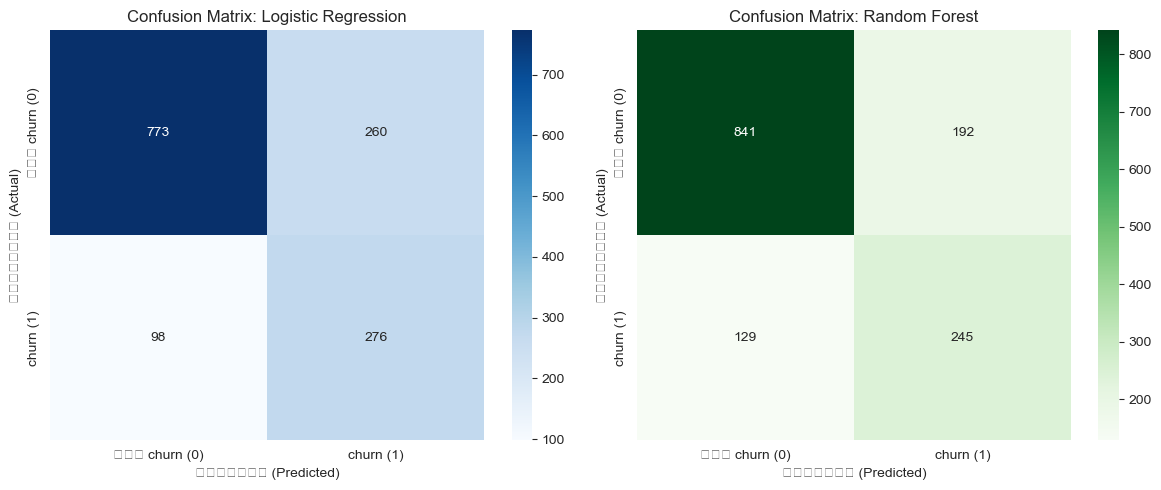

In [11]:
from sklearn.metrics import confusion_matrix

# ปิด warning เรื่องฟอนต์ที่ไม่เกี่ยวข้อง — เกิดจาก matplotlib เช็ค glyph ภาษาไทยกับฟอนต์สำรอง (Arial) ในลิสต์ภายใน
# ทั้งที่ตัวกราฟจริงใช้ฟอนต์ Tahoma ที่รองรับภาษาไทยอยู่แล้ว (ตั้งค่าไว้ตั้งแต่ต้นไฟล์) ข้อความจึงแสดงผลถูกต้องปกติ
import warnings
warnings.filterwarnings('ignore', message='Glyph.*missing from font')

# confusion_matrix(ความจริง, ผลทำนาย) คืนตาราง 2x2 นับจำนวนแต่ละกรณีตามที่อธิบายไว้ข้างบน
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['ไม่ churn (0)', 'churn (1)']
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('ผลทำนาย (Predicted)')
axes[0].set_ylabel('ความจริง (Actual)')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title('Confusion Matrix: Random Forest')
axes[1].set_xlabel('ผลทำนาย (Predicted)')
axes[1].set_ylabel('ความจริง (Actual)')

plt.tight_layout()
plt.show()

### 16.2 Precision, Recall, F1-score และ ROC-AUC

**จะทำอะไร:** คำนวณตัวชี้วัด 4 ตัวสำหรับแต่ละโมเดล โฟกัสที่ class churn=1 โดยเฉพาะ แล้วรวมเป็นตารางเทียบกัน

**ความหมายของแต่ละตัวชี้วัด (แบบเข้าใจง่าย):**
- **Precision (ความแม่นในกลุ่มที่ทายว่า churn):** ในบรรดาคนที่โมเดลทายว่า "จะ churn" มีกี่ % ที่ churn จริง — ถ้า precision ต่ำ
  แปลว่าโมเดล "ตื่นตูม" ทายว่า churn เกินจริงบ่อย ทำให้ทีมธุรกิจเสียเวลา/งบไปดูแลลูกค้าที่จริงๆ ไม่ได้เสี่ยง
- **Recall (ความครอบคลุมกลุ่มที่ churn จริง):** ในบรรดาคนที่ churn จริงทั้งหมด โมเดลจับได้กี่ % — ถ้า recall ต่ำ แปลว่าโมเดล
  "พลาด" ลูกค้าที่กำลังจะเลิกใช้บริการไปเยอะ (False Negative เยอะ) ซึ่งอันตรายกว่า เพราะธุรกิจจะไม่ได้ยื่นมือช่วยรักษาลูกค้ากลุ่มนี้เลย
- **F1-score:** ค่าเฉลี่ยแบบถ่วงน้ำหนักของ Precision กับ Recall (เรียกว่า harmonic mean) ใช้เป็นตัวสรุปตัวเดียวเวลาต้องการดูภาพรวม
  ทั้งสองด้านพร้อมกัน
- **ROC-AUC:** วัดว่าโมเดล "แยกสองกลุ่มออกจากกัน" ได้ดีแค่ไหนโดยไม่ขึ้นกับจุดตัดสินใจ (threshold) เฉพาะจุดใดจุดหนึ่ง ค่าอยู่ระหว่าง
  0.5 (แยกไม่ได้เลย เหมือนทายเดา) ถึง 1.0 (แยกได้สมบูรณ์แบบ) — เป็นตัวชี้วัดที่ใช้เทียบโมเดลกันได้อย่างเป็นธรรมที่สุดตัวหนึ่ง


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
for name, y_pred, model in [('Logistic Regression', y_pred_log_reg, log_reg), ('Random Forest', y_pred_rf, rf)]:
    # .predict_proba(X_test)[:, 1] คืนความน่าจะเป็นที่โมเดลให้กับ "class 1" (churn) ของลูกค้าแต่ละคน
    # ต่างจาก .predict() ที่ตัดสินใจแล้วว่า churn/ไม่ churn, predict_proba ให้ค่าความมั่นใจแบบละเอียด (0.0-1.0) มาก่อน
    # จำเป็นสำหรับคำนวณ ROC-AUC เพราะ ROC-AUC ต้องดูความน่าจะเป็นทุกระดับ ไม่ใช่แค่คำตอบสุดท้าย
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (churn)': precision_score(y_test, y_pred),
        'Recall (churn)': recall_score(y_test, y_pred),
        'F1 (churn)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

comparison_df = pd.DataFrame(results).set_index('Model').round(3)
comparison_df

,Accuracy,Precision (churn),Recall (churn),F1 (churn),ROC-AUC
Model,,,,,
Logistic Regression,0.746,0.515,0.738,0.607,0.827
Random Forest,0.772,0.561,0.655,0.604,0.816


### 16.3 ROC Curve

**จะทำอะไร:** วาดกราฟ ROC curve ของทั้งสองโมเดลในกราฟเดียวกัน เพื่อเห็นภาพว่าโมเดลไหน "โค้งเข้าใกล้มุมบนซ้าย" มากกว่ากัน
(ยิ่งเข้าใกล้มุมบนซ้ายเท่าไหร่ ยิ่งแยกสองกลุ่มได้ดีเท่านั้น)


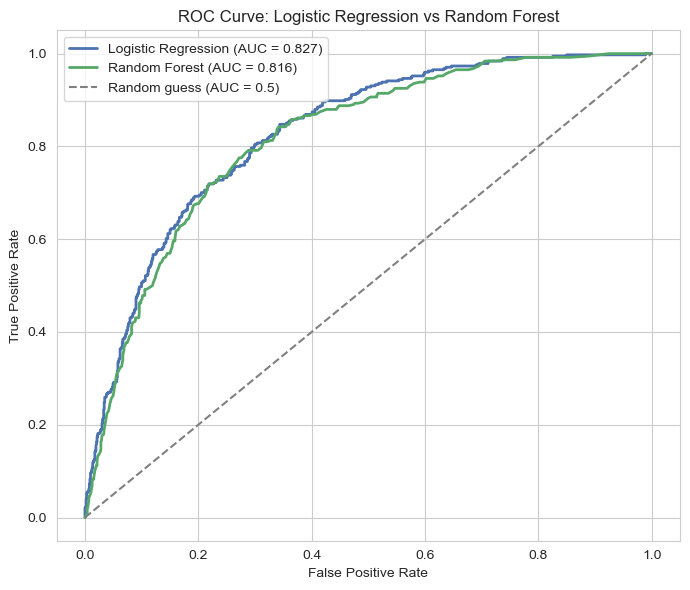

In [13]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))

for name, model, color in [('Logistic Regression', log_reg, '#4C72B0'), ('Random Forest', rf, '#55A868')]:
    y_proba = model.predict_proba(X_test)[:, 1]
    # roc_curve คำนวณคู่ (false positive rate, true positive rate) ที่ threshold ต่างๆ กันหลายร้อยจุด เพื่อวาดเป็นเส้นโค้ง
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', color=color, linewidth=2)

# เส้นทแยงมุม (diagonal) แทนโมเดลที่ "ทายเดาสุ่ม" ล้วนๆ ไม่ได้เรียนรู้อะไรเลย (AUC = 0.5) ใช้เป็นเส้นฐานเปรียบเทียบ
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Logistic Regression vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

**ผลลัพธ์หมายความว่าอย่างไร (สรุปทั้ง 3 หัวข้อย่อยรวมกัน):**

| ตัวชี้วัด | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 74.6% | **77.2%** |
| Precision (churn) | 51.5% | **56.1%** |
| Recall (churn) | **73.8%** | 65.5% |
| F1 (churn) | **0.607** | 0.604 |
| ROC-AUC | **0.827** | 0.816 |

**ไม่มีโมเดลไหนชนะทุกด้าน** — ต้องเลือกตามสิ่งที่ธุรกิจให้ความสำคัญ:

- **Random Forest ชนะด้าน Accuracy และ Precision** — เมื่อทายว่า "จะ churn" มีโอกาสถูกมากกว่า (56.1% เทียบ 51.5%) เหมาะถ้าต้องการ
  ลดการเตือนที่ผิดพลาด (false alarm) เพื่อไม่ให้ทีมรักษาลูกค้าเสียเวลากับคนที่ไม่ได้เสี่ยงจริง
- **Logistic Regression ชนะด้าน Recall** — จับลูกค้าที่ churn จริงได้มากกว่า (73.8% เทียบ 65.5%) แปลว่าพลาดลูกค้าเสี่ยงน้อยกว่า
  ซึ่ง**สำคัญกว่า Precision สำหรับธุรกิจนี้** เพราะการ "พลาด" ลูกค้าที่กำลังจะเลิกใช้บริการ (False Negative) มีต้นทุนสูงกว่าการเตือนผิดพลาด
  (False Positive) — เสียลูกค้าไปเลยแพงกว่าเสียเวลาโทรหาลูกค้าที่ไม่ได้เสี่ยงจริง
- **F1-score ใกล้เคียงกันมาก** (0.607 vs 0.604) แปลว่าโดยรวมทั้งสองโมเดล "สมดุล" ระหว่าง precision/recall พอๆ กัน
- **ROC-AUC ของ Logistic Regression สูงกว่าเล็กน้อย** (0.827 vs 0.816) — ทั้งคู่ถือว่า "ดี" (ค่าเกิน 0.8 ถือว่าแยกสองกลุ่มได้ดี
  เทียบกับ 0.5 ที่แปลว่าทายเดา)

**ข้อสรุป:** ถ้าธุรกิจให้ความสำคัญกับ **"อย่าพลาดลูกค้าที่จะเลิกใช้บริการ"** (ซึ่งสมเหตุสมผลกว่าสำหรับปัญหา churn) **Logistic
Regression เป็นตัวเลือกที่ดีกว่า** เพราะ Recall และ ROC-AUC สูงกว่า ทั้งที่เป็นโมเดลที่ตีความง่ายกว่าด้วย — เป็นกรณีที่โมเดลซับซ้อนกว่า
(Random Forest) ไม่ได้ให้ผลดีกว่าเสมอไป


### 16.4 Cross-Validation Robustness Check ด้วย StratifiedKFold

**จะทำอะไร:** ผลลัพธ์ใน 16.1-16.3 ทั้งหมดมาจากการแบ่ง train/test **แค่ครั้งเดียว** (Step 12.3) — ขั้นตอนนี้ตรวจสอบว่าตัวเลขที่ได้
"นิ่ง" จริงหรือแค่โชคจากการสุ่มแบ่งข้อมูลรอบนั้นรอบเดียว โดยใช้ **StratifiedKFold (5-fold)** สร้างคู่ train/test ใหม่ 5 คู่ที่ไม่ซ้ำกัน
เทรนโมเดลใหม่ทั้งหมดในแต่ละรอบ แล้วดูว่าตัวชี้วัดหลัก (โดยเฉพาะ Recall และ ROC-AUC ที่ใช้สรุปผลใน 16.3) แกว่งมากน้อยแค่ไหนใน 5 รอบนั้น

**StratifiedKFold ทำงานอย่างไร:** แบ่งลูกค้าทั้งหมด (ใช้ `X`, `y` เต็มชุด ก่อนการแบ่ง train/test ใน Step 12.3) ออกเป็น 5 ส่วนเท่าๆ กัน
โดยควบคุมให้แต่ละส่วนมีสัดส่วน churn ใกล้เคียง 26.6% เท่ากันหมด (หลักการเดียวกับ `stratify=y` ใน Step 12.3) จากนั้นวนเทรน 5 รอบ
แต่ละรอบใช้ 4 ส่วนเป็น train และอีก 1 ส่วนที่เหลือเป็น test สลับกันไปจนครบทั้ง 5 ส่วน — ทุกลูกค้าจะได้เป็น "test" มาแล้วพอดี 1 ครั้ง
ไม่มีข้อมูลไหนถูกทิ้งไว้เฉยๆ แบบ single split ที่กัน 20% ไว้ไม่เคยเอาไปเทรนเลย

**ทำไมต้องสร้าง pipeline ใหม่ ห้ามเอา `X_train_smote`/`scaler` จาก Step 12-13 มาใช้ต่อ:** ถ้าเผลอเอาข้อมูลที่ scale/SMOTE
มาแล้วครั้งเดียว (จาก Step 12.4 และ Step 13) มา cross-validate ต่อ จะเกิด **data leakage ซ้ำ 5 เท่า** เพราะ `StandardScaler`
และ `SMOTE` จะถูก fit จากข้อมูลที่ "รู้" ค่าเฉลี่ย/รูปแบบของทุก fold ไปแล้วตั้งแต่ต้น ทำให้แต่ละ fold ไม่ได้เป็นอิสระจากกันจริง
วิธีที่ถูกต้องคือห่อขั้นตอน **scale → SMOTE → train** ทั้งหมดไว้ใน `imblearn.pipeline.Pipeline` เดียว แล้วให้ `cross_validate`
เรียก fit ใหม่ทั้ง pipeline ในทุกรอบ โดยเห็นแค่ 4 ส่วนที่เป็น train ของรอบนั้นเท่านั้น (ใช้ Pipeline ของ `imblearn` แทนของ `sklearn`
เพราะ SMOTE ต้องปรับทั้ง X และ y พร้อมกัน ซึ่ง Pipeline ปกติของ sklearn ไม่รองรับขั้นตอนแบบนี้)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline

# ColumnTransformer: scale เฉพาะ numeric_cols (tenure, MonthlyCharges, TotalCharges) เหมือน Step 12.4
# คอลัมน์ categorical ที่ one-hot แล้ว (เป็น 0/1 อยู่แล้ว) ปล่อยผ่านไปเฉยๆ ด้วย remainder='passthrough'
preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)

# แต่ละ pipeline ห่อ 3 ขั้นตอนไว้ด้วยกัน: ปรับสเกล -> ทำ SMOTE -> เทรนโมเดล
# cross_validate จะเรียก fit ทั้ง pipeline นี้ใหม่ทุกรอบ โดยเห็นแค่ 4/5 ส่วนที่เป็น train ของรอบนั้นเท่านั้น (ไม่มีทาง leak ไปเห็น fold ที่เป็น test)
pipelines = {
    'Logistic Regression': ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42))
    ])
}

# shuffle=True + random_state=42: สุ่มลำดับก่อนแบ่ง fold ให้ reproducible (ถ้าไม่ shuffle ลำดับเดิมในไฟล์อาจทำให้แบ่ง fold ไม่เป็นตัวแทนที่ดี)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# วัดผลด้วยตัวชี้วัดชุดเดียวกับ Step 16.2 เพื่อเทียบกันได้ตรงๆ
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
for name, pipe in pipelines.items():
    # cross_validate ทำหน้าที่ทั้งหมดในตัวเดียว: แบ่ง fold ตาม skf, fit pipeline ใหม่ในแต่ละรอบ, ทำนาย, คำนวณ metric ทุกตัวใน scoring
    # ใช้ X, y เต็มชุด (ไม่ใช่ X_train/X_test จาก Step 12.3) เพราะ K-Fold ต้องการหมุนเวียนใช้ข้อมูลทุกแถวเป็น test
    cv_results[name] = cross_validate(pipe, X, y, cv=skf, scoring=scoring)

cv_summary = []
for name, scores in cv_results.items():
    row = {'Model': name}
    for metric in scoring:
        vals = scores[f'test_{metric}']
        row[f'{metric} (mean)'] = vals.mean()
        row[f'{metric} (std)'] = vals.std()
    cv_summary.append(row)

cv_summary_df = pd.DataFrame(cv_summary).set_index('Model').round(3)
cv_summary_df


,accuracy (mean),accuracy (std),precision (mean),precision (std),recall (mean),recall (std),f1 (mean),f1 (std),roc_auc (mean),roc_auc (std)
Model,,,,,,,,,,
Logistic Regression,0.752,0.007,0.522,0.009,0.796,0.017,0.630,0.011,0.845,0.003
Random Forest,0.787,0.004,0.602,0.009,0.591,0.019,0.596,0.010,0.826,0.007


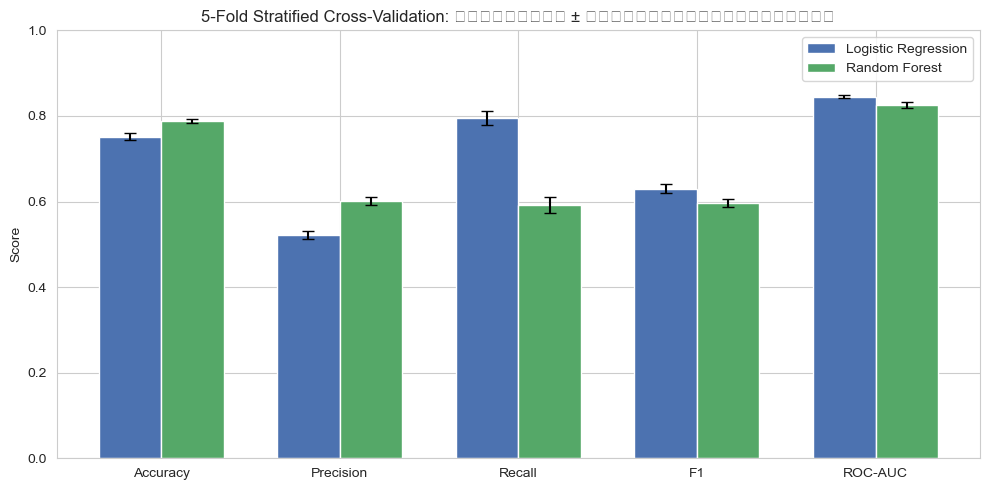

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

metric_labels = {'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1', 'roc_auc': 'ROC-AUC'}
x = np.arange(len(scoring))
width = 0.35

for i, (name, color) in enumerate([('Logistic Regression', '#4C72B0'), ('Random Forest', '#55A868')]):
    means = [cv_results[name][f'test_{m}'].mean() for m in scoring]
    stds = [cv_results[name][f'test_{m}'].std() for m in scoring]
    # yerr=stds วาด error bar แสดงส่วนเบี่ยงเบนมาตรฐานของแต่ละ metric จาก 5 fold — แท่งที่มี error bar สั้น = ผลลัพธ์นิ่ง, ยาว = แกว่งเยอะ
    ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4, label=name, color=color)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in scoring])
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('5-Fold Stratified Cross-Validation: ค่าเฉลี่ย ± ส่วนเบี่ยงเบนมาตรฐาน')
ax.legend()
plt.tight_layout()
plt.show()


**ผลลัพธ์หมายความว่าอย่างไร:**

| ตัวชี้วัด (5-fold CV) | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 75.2% ± 0.7% | **78.7% ± 0.4%** |
| Precision (churn) | 52.2% ± 0.9% | **60.2% ± 0.9%** |
| Recall (churn) | **79.6% ± 1.7%** | 59.1% ± 1.9% |
| F1 (churn) | **0.630 ± 0.011** | 0.596 ± 0.010 |
| ROC-AUC | **0.845 ± 0.003** | 0.826 ± 0.007 |

**ส่วนเบี่ยงเบนมาตรฐาน (std) เล็กมากในทุกตัวชี้วัด** (ส่วนใหญ่ไม่เกิน ±0.02) — แปลว่าไม่ว่าจะสุ่มแบ่งข้อมูลเป็น 5 รูปแบบที่ต่างกันแค่ไหน
ผลลัพธ์ของทั้งสองโมเดลก็ไม่เปลี่ยนทิศทาง **ข้อสรุปเรื่องการเลือกโมเดลจาก Step 16.2-16.3 จึงเชื่อถือได้จริง ไม่ได้เกิดจากโชคของการสุ่มแบ่งข้อมูลรอบเดียว**

**เทียบกับตัวเลขจาก single 80/20 split (16.2):** ทิศทางเหมือนกันทุกตัวชี้วัด (Random Forest ชนะ Accuracy/Precision, Logistic
Regression ชนะ Recall/ROC-AUC) แต่มีจุดที่น่าสนใจคือ **ช่องว่างด้าน Recall ระหว่างสองโมเดลกว้างกว่าที่ single split เคยแสดงให้เห็น** —
single split บอกว่า Logistic Regression นำ Random Forest อยู่ 8.3 จุด (73.8% vs 65.5%) แต่ค่าเฉลี่ยจาก 5-fold บอกว่านำอยู่ถึง 20.5 จุด
(79.6% vs 59.1%) ซึ่งห่างกันเกินกว่า 1 std ของทั้งสองโมเดลชัดเจน (ไม่ใช่แค่ความคลาดเคลื่อนจากการสุ่มเฉยๆ) แปลว่า **single split ที่ใช้ใน
Step 16.1-16.3 เดิม ประเมินความได้เปรียบด้าน Recall ของ Logistic Regression ไว้ต่ำกว่าความเป็นจริงเล็กน้อย** — ข้อสรุปที่ว่า Logistic
Regression เหมาะกับธุรกิจนี้มากกว่าเพราะจับลูกค้าเสี่ยงได้ครอบคลุมกว่า จึงยิ่งมีน้ำหนักมากขึ้นไปอีกเมื่อตรวจสอบด้วย cross-validation
ไม่ใช่ลดน้ำหนักลง

**สรุป 16.4:** 5-fold Stratified Cross-Validation ยืนยันว่าผลการเปรียบเทียบโมเดลใน Step 16.1-16.3 ไม่ได้เกิดจากความบังเอิญของการแบ่ง
ข้อมูลรอบเดียว — Logistic Regression ยังคงเป็นตัวเลือกที่เหมาะกับเป้าหมายทางธุรกิจมากกว่า (Recall/ROC-AUC สูงกว่าอย่างเห็นได้ชัดและนิ่ง
ในทุก fold) ในขณะที่ Random Forest แม่นยำกว่าในภาพรวม (Accuracy/Precision) เหมือนเดิม


### 16.5 Learning Curve — ตรวจสอบว่าสัดส่วน 80/20 ให้ข้อมูล train เพียงพอหรือไม่

**ที่มา:** Step 16.4 ตอบคำถามแล้วว่าผลลัพธ์จาก single 80/20 split "เชื่อถือได้" (ไม่ได้เกิดจากโชคของการสุ่มแบ่งข้อมูล) แต่ยังไม่ได้ตอบอีก
คำถามหนึ่งที่แยกกันโดยสิ้นเชิงคือ **"80% ที่ใช้เทรนอยู่ตอนนี้ เป็นปริมาณที่ 'พอดี' แล้วหรือยัง"** — ถ้าเพิ่มข้อมูล train อีก โมเดลจะดีขึ้นอีกไหม
(แปลว่า 80% ยังน้อยไป) หรือถ้าเพิ่มข้อมูล train ไปแล้วผลไม่ต่างจากเดิม (แปลว่า 80% มากเกินความจำเป็นแล้ว น่าจะลดสัดส่วน train ลงเพื่อให้
test set ใหญ่ขึ้นแทนได้) คำถามนี้ต้องใช้ **Learning Curve** ตอบโดยเฉพาะ

**Learning Curve คืออะไร (แบบเข้าใจง่าย):** ลองนึกภาพการสอบซ้อมก่อนสอบจริง — ถ้าอ่านหนังสือแค่ 10% ของเนื้อหาแล้วสอบซ้อม จะทำคะแนนได้แย่
ทั้งตอนซ้อม (โจทย์ที่เพิ่งอ่านผ่านมา) และตอนสอบจริง (โจทย์ที่ไม่เคยเห็น) แต่พอเริ่มอ่านมากขึ้นเรื่อยๆ (20%, 40%, ... จนถึง 100%) คะแนนสอบซ้อม
กับคะแนนสอบจริงจะเริ่ม **"บรรจบกัน"** ที่จุดหนึ่ง — Learning Curve คือกราฟที่วาดคะแนนทั้งสองแบบนี้ (train score, validation score) เทียบกับ
ปริมาณข้อมูลที่ใช้ train ตั้งแต่น้อยไปมาก เพื่อดูว่าเส้นสองเส้นนี้บรรจบกันหรือยังตอนถึงปริมาณข้อมูลที่ใช้อยู่จริง (80%)

**กลไกการทำงาน:** `sklearn.model_selection.learning_curve` ทำสิ่งนี้ให้อัตโนมัติ — กำหนดขนาด train ที่จะลอง 8 ระดับ (10% ถึง 100% ของ
train partition ในแต่ละ fold) สำหรับแต่ละระดับ มันจะ:
1. สุ่มตัดข้อมูล train เหลือแค่สัดส่วนที่กำหนด (เช่น 30%) จาก train partition ของแต่ละ fold ใน `skf` (5-fold เดียวกับที่ใช้ใน Step 16.4)
2. เทรนโมเดลใหม่ด้วยข้อมูล subset นั้น แล้ววัดคะแนนย้อนกลับบนข้อมูล subset เดียวกันที่เพิ่งเทรน (**train score**)
3. เอาโมเดลตัวเดียวกันไปวัดคะแนนกับ validation fold ที่ไม่เคยเห็นเลย (**validation score**)
4. ทำซ้ำแบบนี้ครบทั้ง 5 fold แล้วเฉลี่ย ได้ mean ± std ของทั้ง train score และ validation score ที่ระดับข้อมูลนั้น

ทำซ้ำทั้ง 8 ระดับ แล้วพล็อตเป็นกราฟเส้น 2 เส้น (train, validation) เทียบกับจำนวนตัวอย่าง — เส้นแนวตั้งจุดไข่ปลาทำเครื่องหมายตำแหน่งขนาด
train ปัจจุบัน (80% ของข้อมูลทั้งหมด ~5,634 แถว) เพื่อดูว่า ณ จุดนั้น เส้นทั้งสองเริ่มราบ (plateau) แล้วหรือยัง — ใช้ **Recall** เป็นตัวชี้วัด
เพราะเป็นตัวชี้วัดหลักที่ใช้ตัดสินเลือกโมเดลในข้อสรุปของ Step 16 (การพลาดลูกค้าที่จะ churn มีต้นทุนสูงกว่า)

**วิธีอ่านผล:**
- **เส้น validation ยังไต่ขึ้นชัดเจนที่จุด 80%:** โมเดลยังได้ประโยชน์จากข้อมูล train เพิ่มอยู่ → 80% ยังไม่ใช่จุดที่ "พอดี" ควรเพิ่มสัดส่วน
  train (ลด test ลง) เพื่อให้โมเดลเรียนรู้ได้เต็มที่กว่านี้
- **เส้น validation ราบแล้วก่อนถึง 80%:** เพิ่มข้อมูล train อีกก็ไม่ช่วยอะไร → 80% มากเกินความจำเป็น สามารถลดลงเพื่อให้ test set ใหญ่ขึ้น
  (วัดผลแม่นขึ้นตามที่คุยกันไปก่อนหน้า) ได้โดยไม่เสียประสิทธิภาพโมเดล
- **ช่องว่างระหว่างเส้น train กับ validation กว้างและไม่แคบลงเลยแม้เพิ่มข้อมูล:** สัญญาณของ **overfitting** ที่ไม่ได้เกิดจากปริมาณข้อมูลน้อย
  (เพิ่มข้อมูลเท่าไหร่ก็ไม่ช่วยปิดช่องว่าง) ต้องแก้ที่ความซับซ้อนของโมเดลแทน ไม่ใช่แก้ที่สัดส่วน split


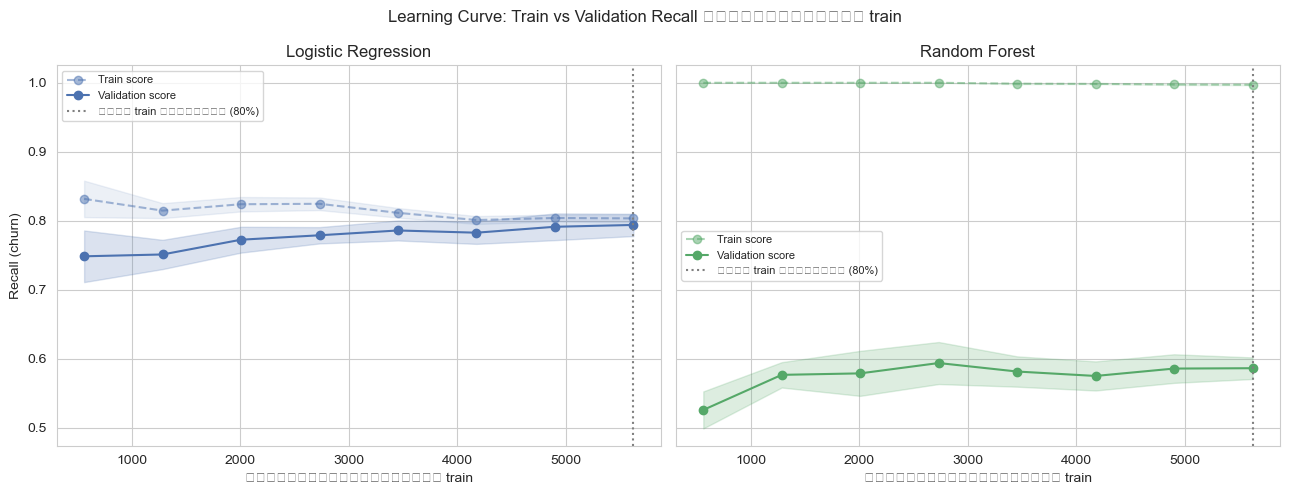

In [16]:
from sklearn.model_selection import learning_curve

# 8 ระดับของขนาด train ที่จะลอง ตั้งแต่ 10% ถึง 100% ของ train partition ในแต่ละ fold ของ skf (นิยามไว้แล้วใน Step 16.4)
train_sizes_frac = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (name, color) in zip(axes, [('Logistic Regression', '#4C72B0'), ('Random Forest', '#55A868')]):
    # learning_curve วนเทรนโมเดลใหม่ทุกระดับขนาด x ทุก fold ของ skf แล้ววัด recall ทั้งบนข้อมูลที่เพิ่งเทรน (train_scores)
    # และบน validation fold ที่ไม่เคยเห็นเลย (val_scores) — คืน array ขนาด (8 ระดับ, 5 fold)
    train_sizes_abs, train_scores, val_scores = learning_curve(
        pipelines[name], X, y,
        train_sizes=train_sizes_frac, cv=skf, scoring='recall', n_jobs=-1
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes_abs, train_mean, 'o--', color=color, alpha=0.5, label='Train score')
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color=color)

    ax.plot(train_sizes_abs, val_mean, 'o-', color=color, label='Validation score')
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.2, color=color)

    # เส้นแนวตั้งจุดไข่ปลา บอกตำแหน่งขนาด train ปัจจุบันที่ใช้จริงใน Step 12.3 (80% ของข้อมูลทั้งหมด ~5,634 แถว)
    ax.axvline(x=len(X) * 0.8, linestyle=':', color='gray', label='ขนาด train ปัจจุบัน (80%)')

    ax.set_title(name)
    ax.set_xlabel('จำนวนตัวอย่างที่ใช้ train')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Recall (churn)')
fig.suptitle('Learning Curve: Train vs Validation Recall ตามขนาดข้อมูล train')
plt.tight_layout()
plt.show()


**ผลลัพธ์หมายความว่าอย่างไร:**

**Logistic Regression:** เส้น validation recall ไต่จาก 74.9% (ที่ train 562 แถว) ขึ้นมาที่ 78.6% ตอน train ~3,455 แถว แล้วแทบไม่ขยับอีกเลย
จนถึงขนาด train ปัจจุบัน (5,625 แถว = 80% ของข้อมูลทั้งหมด) ซึ่งอยู่ที่ 79.4% — การขยับขึ้นช่วงหลัง (~0.8 จุด) เล็กกว่า std ของแต่ละจุด
(~1.4-1.9 จุด) จึงถือว่า **เส้น validation "ราบ" (plateau) ไปแล้วตั้งแต่ประมาณ train ~2,700-3,500 แถว** ช่องว่างระหว่าง train score
(80.4%) กับ validation score (79.4%) ที่ขนาด 80% ก็แคบมาก (~1 จุด) — สรุปคือ **สำหรับ Logistic Regression, 80% เป็นสัดส่วน train ที่
"เกินพอ" แล้ว** ลดสัดส่วน train ลงเหลือ ~60-70% (เพื่อให้ test set ใหญ่ขึ้น วัดผลแม่นขึ้นตามที่คุยกันไปก่อนหน้า) น่าจะยังให้ recall
ใกล้เคียงเดิม โดยไม่เสียประสิทธิภาพโมเดลไปมาก

**Random Forest:** ภาพต่างไปโดยสิ้นเชิง — train score คงที่อยู่ที่ ~100% (แม่นยำเกือบสมบูรณ์แบบ) ตั้งแต่ขนาด train เล็กที่สุดไปจนใหญ่ที่สุด
ในขณะที่ validation score แกว่งอยู่แถว 53-59% ตลอดทั้งเส้น **ไม่มีแนวโน้มไต่ขึ้นชัดเจนเลยแม้เพิ่มข้อมูล train จาก 562 เป็น 5,625 แถว (10 เท่า)**
ช่องว่างระหว่าง train (~100%) กับ validation (~58%) ใหญ่มากและ**ไม่แคบลงเลย** นี่คือลายเซ็นคลาสสิกของ **overfitting ที่มาจากความซับซ้อน
ของโมเดล ไม่ใช่จากปริมาณข้อมูล** (`RandomForestClassifier` ที่ไม่ได้จำกัด `max_depth` จะขยายกิ่งจนจำข้อมูล train ได้เกือบหมดทุกครั้ง
ไม่ว่าจะมีข้อมูลกี่แถวก็ตาม) — สรุปคือ **สำหรับ Random Forest สัดส่วน train/test ไม่ใช่ปัจจัยที่จำกัดผลลัพธ์เลย** ต่อให้เพิ่ม train
เป็น 90% หรือ 95% recall บน validation ก็แทบไม่น่าจะดีขึ้น เพราะปัญหาที่แท้จริงคือความซับซ้อนของโมเดล (ต้องแก้ด้วยการจำกัด `max_depth`/
`min_samples_leaf` ไม่ใช่แก้ที่สัดส่วน split)

**สรุป 16.5 — ตอบคำถามที่ค้างไว้ว่า "80/20 ถูกต้องหรือไม่":** คำตอบขึ้นกับโมเดล ไม่มีคำตอบเดียวที่ใช้ได้กับทุกโมเดล

- Logistic Regression (โมเดลที่ Step 16 สรุปว่าเหมาะกับธุรกิจนี้ที่สุด) **ได้ประโยชน์เต็มที่จาก 80/20 แล้ว และยังมีข้อมูล train เหลือเฟือ**
  ตอบคำถามเรื่อง "สัดส่วนถูกต้องไหม" ได้ตรงๆ ว่า **ถูกต้อง (หรือให้ train มากกว่าที่จำเป็นด้วยซ้ำ)**
- Random Forest มีปัญหาอยู่ที่ตัวโมเดลเอง ไม่เกี่ยวกับสัดส่วน split — การเปลี่ยนสัดส่วนจะไม่ช่วยแก้ recall ที่ต่ำของมันเลย

เมื่อรวมกับ Step 16.4 (ยืนยันว่าผลลัพธ์นิ่ง ไม่ใช่โชคจากการสุ่มแบ่งข้อมูล) และ Learning Curve ในหัวข้อนี้ (ยืนยันว่า 80% ให้ข้อมูล train
เพียงพอสำหรับโมเดลที่เลือกใช้จริงคือ Logistic Regression) จึงสรุปได้อย่างมั่นใจว่า **สัดส่วน 80/20 ที่ใช้อยู่ใน Step 12.3 เหมาะสมกับ
โปรเจกต์นี้แล้ว** ไม่จำเป็นต้องปรับสัดส่วนแต่อย่างใด


**สรุป Step 16:** เปรียบเทียบทั้ง 2 โมเดลอย่างละเอียดครบทุกมุม (Confusion Matrix, Precision/Recall/F1, ROC-AUC/ROC Curve) ตรวจสอบ
ความนิ่งด้วย 5-fold Stratified Cross-Validation (16.4) และตรวจสอบว่าสัดส่วน train/test ปัจจุบันเพียงพอหรือไม่ด้วย Learning Curve (16.5)
แล้วพบว่า Logistic Regression เหมาะกับเป้าหมายทางธุรกิจมากกว่าอย่างชัดเจนและสม่ำเสมอในทุก fold เพราะจับลูกค้าเสี่ยงได้ครอบคลุมกว่า
แม้ Random Forest จะแม่นยำกว่าในภาพรวม

ขั้นตอนถัดไป (Step 17) จะเจาะลึกว่า **feature ไหน** ที่แต่ละโมเดลให้น้ำหนักมากที่สุดในการทำนาย แล้วเทียบกับ insight เชิงสถิติจาก EDA


## Step 17: Feature Importance & Interpretation (ดูว่าปัจจัยไหนมีน้ำหนักมากที่สุด)

**จะทำอะไร:** Step 16 บอกแล้วว่าโมเดลไหนแม่นยำกว่า แต่ยังไม่ได้ตอบว่า **"โมเดลใช้ปัจจัยอะไรในการตัดสินใจ"** — Step นี้จะเจาะดูน้ำหนัก
ที่แต่ละโมเดลให้กับแต่ละ feature แบ่งเป็น 3 หัวข้อย่อย: (17.1) coefficient ของ Logistic Regression (17.2) feature importance ของ
Random Forest (17.3) เทียบทั้งสองอย่างกับผลสถิติจาก EDA (Step 5-6) ว่าตรงกันหรือไม่

**ทำไมต้องเทียบ 3 วิธีพร้อมกัน:** ถ้าทั้ง 3 วิธี (Chi-square/Mann-Whitney จาก EDA, coefficient ของ Logistic Regression,
feature importance ของ Random Forest) ชี้ไปทาง feature เดียวกันว่าสำคัญ นั่นคือหลักฐานที่หนักแน่นกว่าดูวิธีเดียวมาก — เพราะแต่ละวิธี
มีจุดอ่อนต่างกัน (สถิติไม่ได้ควบคุมตัวแปรอื่น, Logistic Regression ไวต่อ multicollinearity, Random Forest อาจให้น้ำหนักสูงกับ
feature ที่มีหลายหมวดหมู่โดยไม่ได้ตั้งใจ) การที่ทั้ง 3 เห็นตรงกันจึงน่าเชื่อถือกว่า


### 17.1 Logistic Regression Coefficients

**จะทำอะไร:** ดึงค่า `.coef_` ของโมเดล Logistic Regression มาจับคู่กับชื่อ feature แต่ละตัว แล้วเรียงจากน้ำหนักเยอะสุดไปน้อยสุด

**วิธีอ่านค่า coefficient:** เนื่องจากโมเดลนี้เทรนบนข้อมูลที่เข้ารหัสแบบ One-Hot (Step 12) และ scale ตัวเลขแล้ว coefficient แต่ละตัว
มีความหมายคือ **"ทิศทางและขนาดผลกระทบต่อโอกาส churn"**:
- **coefficient เป็นบวก (+):** feature นั้นทำให้โอกาส churn **เพิ่มขึ้น**
- **coefficient เป็นลบ (−):** feature นั้นทำให้โอกาส churn **ลดลง**
- **ขนาดของตัวเลข (ไม่สนใจเครื่องหมาย):** ยิ่งมากเท่าไหร่ ยิ่งมีอิทธิพลต่อการทำนายมากเท่านั้น


In [17]:
# สร้างตารางจับคู่ชื่อ feature กับค่า coefficient ของมัน
# log_reg.coef_ มีรูปร่างเป็น array 2 มิติ (1 แถว x จำนวน feature) เพราะเป็นปัญหา binary classification จึงดึง [0] ออกมาเป็น 1 มิติ
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
})

# สร้างคอลัมน์ค่าสัมบูรณ์ (ไม่สนเครื่องหมาย) ไว้ใช้เรียงลำดับความสำคัญ
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

top10_coef = coef_df.head(10)
top10_coef[['feature', 'coefficient']]

,feature,coefficient
0,MonthlyCharges,7.242989
1,InternetService_Fiber optic,-5.213030
2,PhoneService_Yes,-3.557017
3,StreamingTV_Yes,-2.234256
4,StreamingMovies_Yes,-2.215670
5,OnlineSecurity_Yes,-1.992204
6,TechSupport_Yes,-1.899687
7,MultipleLines_No phone service,1.880958
8,Contract_Two year,-1.658920
9,OnlineBackup_Yes,-1.633048


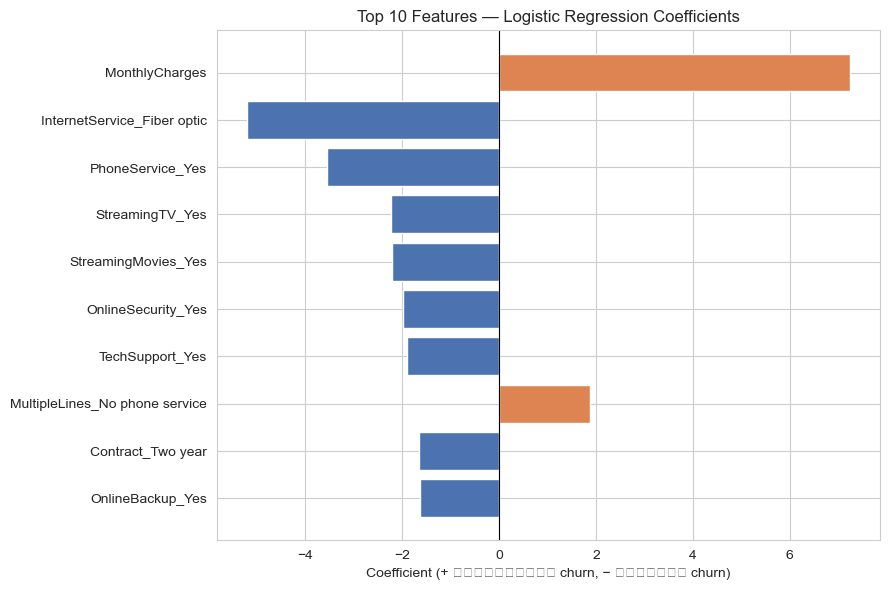

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

# กำหนดสี: บวก (เพิ่มโอกาส churn) เป็นสีส้ม, ลบ (ลดโอกาส churn) เป็นสีน้ำเงิน
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in top10_coef['coefficient']]

# เรียงจากบนลงล่างให้ feature ที่สำคัญที่สุดอยู่บนสุด (invert_yaxis)
ax.barh(top10_coef['feature'], top10_coef['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (+ เพิ่มโอกาส churn, − ลดโอกาส churn)')
ax.set_title('Top 10 Features — Logistic Regression Coefficients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**ผลลัพธ์หมายความว่าอย่างไร:** feature ที่มีน้ำหนักมากที่สุดคือ `MonthlyCharges` (+7.24) — ยิ่งค่าบริการต่อเดือนสูง ยิ่งเพิ่มโอกาส
churn ตรงกับที่เจอใน Step 6 (คนที่ churn จ่ายแพงกว่าคนที่ยังอยู่) ส่วน `OnlineSecurity_Yes`, `TechSupport_Yes`, `OnlineBackup_Yes`,
`Contract_Two year` ล้วนเป็นค่าลบ (ลดโอกาส churn) **ตรงกับ EDA ทุกตัว** — ยืนยันว่าการมีบริการเสริมและสัญญาระยะยาวช่วยรักษาลูกค้าจริง

**จุดที่ต้องระวัง (ขัดแย้งกับ EDA):** `InternetService_Fiber optic` มีค่า **ลบ (-5.21)** ซึ่งแปลตรงตัวว่า "การใช้ Fiber optic ลดโอกาส
churn" — **ขัดกับ Step 5 ที่เจอว่า Fiber optic มี churn rate สูงสุด (41.9%)** อย่างชัดเจน! นี่ไม่ใช่ความผิดพลาด แต่เป็นผลของ
**multicollinearity** ที่เตือนไว้ตั้งแต่ Step 7 พอดี — เช็คแล้วพบว่าลูกค้า Fiber optic จ่ายค่าบริการเฉลี่ยสูงถึง 91.50 บาท เทียบกับ DSL
58.09 บาท และ No internet 21.08 บาท (correlation ระหว่างการเป็นลูกค้า Fiber optic กับ MonthlyCharges สูงถึง 0.79) เมื่อโมเดลมีทั้ง
`MonthlyCharges` และ `InternetService_Fiber optic` พร้อมกัน มันจะ "แบ่งความรับผิดชอบ" ของผลกระทบเดียวกันไปให้ทั้งสองตัวแปร ทำให้
coefficient ของแต่ละตัวแปรเดี่ยวๆ ตีความตรงไปตรงมาไม่ได้อีกต่อไป (ผลกระทบรวมของทั้งสองตัวแปรยังคงถูกต้อง แค่แยกสัดส่วนกันไม่ได้ชัดเจน)

**บทเรียนสำคัญ:** เมื่อ feature มีความสัมพันธ์กันเองสูง (multicollinearity) การดู coefficient ของ Logistic Regression ทีละตัวอาจทำให้
เข้าใจผิดได้ ต้องดูควบคู่กับผลสถิติเชิงพรรณนา (Step 5-6) และ feature importance ของโมเดลอื่น (Step 17.2) เพื่อยืนยันทิศทางที่แท้จริง


### 17.2 Random Forest Feature Importances

**จะทำอะไร:** ดึงค่า `.feature_importances_` ของ Random Forest มาจับคู่กับชื่อ feature แล้วเรียงจากสำคัญสุดไปน้อยสุด

**feature_importances_ คืออะไร (แบบเข้าใจง่าย):** วัดว่า feature นั้นถูกใช้ "แยกกลุ่ม" ในต้นไม้ทั้ง 200 ต้นบ่อยแค่ไหนและช่วยแยก
กลุ่ม churn/ไม่ churn ได้ชัดเจนแค่ไหนทุกครั้งที่ถูกใช้ — ค่าทั้งหมดรวมกันเท่ากับ 1.0 เสมอ (คิดเป็นสัดส่วน % ของ "ความสำคัญรวม")
**ข้อดีเทียบกับ coefficient ของ Logistic Regression:** ไม่ได้รับผลกระทบจาก multicollinearity รุนแรงเท่า เพราะต้นไม้แต่ละต้นสุ่มดู
แค่บาง feature ในแต่ละครั้ง (ตามที่อธิบายไว้ใน Step 15) จึงกระจายความสำคัญระหว่าง feature ที่สัมพันธ์กันได้เป็นธรรมกว่า
**ข้อเสีย:** ไม่บอกทิศทาง (บวก/ลบ) เหมือน coefficient — บอกแค่ "สำคัญแค่ไหน" ไม่บอกว่า "เพิ่มหรือลด" โอกาส churn


In [19]:
# rf.feature_importances_ คืนค่าความสำคัญของแต่ละ feature เป็น array ตามลำดับคอลัมน์เดียวกับตอนเทรน (X_train.columns)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

top10_importance = importance_df.head(10)
top10_importance

,feature,importance
0,tenure,0.174384
1,TotalCharges,0.153244
2,MonthlyCharges,0.142341
3,Contract_Two year,0.061957
4,OnlineSecurity_Yes,0.044051
5,InternetService_Fiber optic,0.037298
6,Contract_One year,0.036976
7,TechSupport_Yes,0.033785
8,PaymentMethod_Electronic check,0.032192
9,gender_Male,0.024292


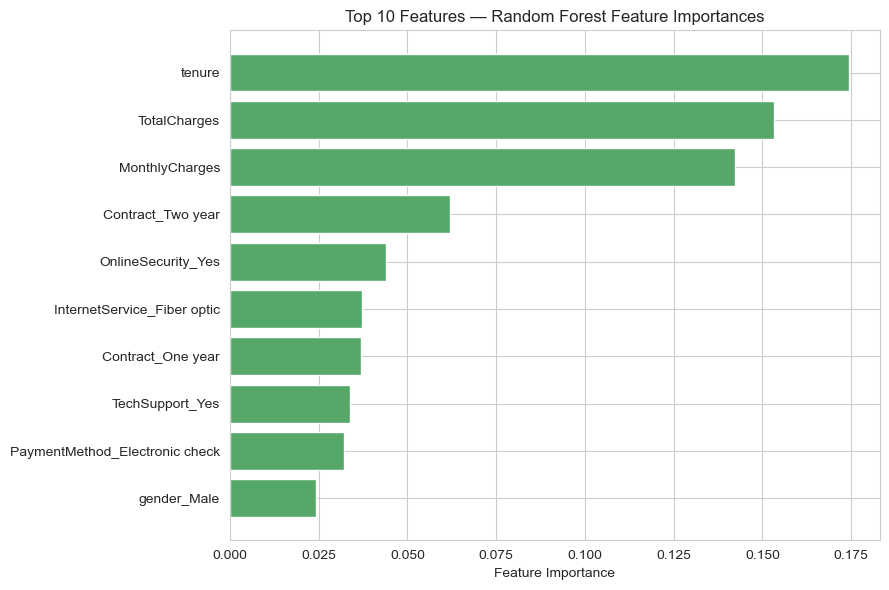

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10_importance['feature'], top10_importance['importance'], color='#55A868')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Features — Random Forest Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**ผลลัพธ์หมายความว่าอย่างไร:** Random Forest ให้น้ำหนักสูงสุดกับ `tenure` (17.4%), `TotalCharges` (15.3%), และ
`MonthlyCharges` (14.2%) รวมกันเกือบครึ่งหนึ่งของความสำคัญทั้งหมด ตามมาด้วย `Contract_Two year`, `OnlineSecurity_Yes`,
`InternetService_Fiber optic`, `Contract_One year`, `TechSupport_Yes`, `PaymentMethod_Electronic check`

**ข้อสังเกตที่ต้องระวัง:** `gender_Male` ติดอันดับ 10 ทั้งที่ Step 5 ยืนยันด้วย Chi-square test แล้วว่า **gender ไม่มีนัยสำคัญทางสถิติ
กับ Churn เลย** (p-value สูงมาก) — นี่เป็นข้อจำกัดของ feature importance ที่ต้องรู้ไว้: Random Forest จะให้ค่าความสำคัญที่ **มากกว่า 0
เสมอ** กับทุก feature (ไม่มีทางเป็น 0 เป๊ะ) แม้ feature นั้นจะไม่มีความสัมพันธ์จริงกับ target เลยก็ตาม เพราะต้นไม้แต่ละต้นอาจบังเอิญใช้
feature นั้นแบ่งกลุ่มได้บ้างจากความบังเอิญของการสุ่มตัวอย่าง จึงต้อง**เทียบกับผลทดสอบสมมติฐานทางสถิติ (Step 5-6) เสมอ** ก่อนสรุปว่า
feature ไหน "สำคัญจริง" ไม่ใช่ดูอันดับความสำคัญจาก Random Forest อย่างเดียว


### 17.3 เทียบผลทั้ง 3 วิธี: สถิติ (EDA) vs Logistic Regression vs Random Forest

| Feature | EDA (Step 5-7) | Logistic Regression | Random Forest | สรุป |
|---|---|---|---|---|
| `tenure` | สัมพันธ์ชัดเจนที่สุด (correlation -0.35) | ไม่ติด Top 10 | **อันดับ 1** (17.4%) | Random Forest กับ EDA เห็นตรงกัน |
| `Contract` (Two year/One year) | churn 2.8%/11.3% เทียบ 42.7% (Month-to-month) | ลบ (ลดโอกาส churn) ✅ | ติด Top 10 ทั้งคู่ | **ตรงกันทั้ง 3 วิธี** |
| `OnlineSecurity_Yes` | churn 14.6% เทียบ 41.8% (ไม่มี) | ลบ (ลดโอกาส churn) ✅ | ติด Top 10 | **ตรงกันทั้ง 3 วิธี** |
| `TechSupport_Yes` | churn 15.2% เทียบ 41.6% (ไม่มี) | ลบ (ลดโอกาส churn) ✅ | ติด Top 10 | **ตรงกันทั้ง 3 วิธี** |
| `MonthlyCharges` | ยิ่งแพงยิ่ง churn เยอะ | บวกสูงสุด (+7.24) ✅ | ติด Top 10 | **ตรงกันทั้ง 3 วิธี** |
| `InternetService_Fiber optic` | churn สูงสุด (41.9%) | **ลบ (-5.21) ขัดแย้ง** ⚠️ | ติด Top 10 (ไม่บอกทิศทาง) | EDA + RF ตรงกัน, LR ขัดแย้งเพราะ multicollinearity กับ MonthlyCharges |
| `gender` | ไม่มีนัยสำคัญ (p-value สูง) | ไม่ติด Top 10 | ติด Top 10 (อันดับ 10) | EDA + LR ตรงกันว่าไม่สำคัญ, RF ให้ความสำคัญเกินจริงเล็กน้อย |

**ข้อสรุปสำคัญ:** ปัจจัยที่ **ทั้ง 3 วิธีเห็นตรงกัน** (Contract, OnlineSecurity, TechSupport, MonthlyCharges) คือปัจจัยที่มั่นใจได้มาก
ที่สุดว่าเป็นตัวขับเคลื่อน Churn จริง ส่วนกรณีที่ขัดแย้งกัน (Fiber optic ใน Logistic Regression, gender ใน Random Forest) ไม่ได้แปลว่า
วิธีใดวิธีหนึ่งผิด แต่เป็นข้อจำกัดเฉพาะตัวของแต่ละเทคนิคที่ต้องรู้เท่าทัน — **การใช้หลายวิธีร่วมกันช่วยกรองข้อผิดพลาดของแต่ละวิธีออกไปได้**


**สรุป Step 17:** เปรียบเทียบ feature importance จาก 3 มุมมอง (สถิติ EDA, Logistic Regression coefficient, Random Forest
importance) พบว่า **Contract, OnlineSecurity, TechSupport, และ MonthlyCharges** คือปัจจัยที่ทั้ง 3 วิธียืนยันตรงกันว่าขับเคลื่อน
Churn จริง ส่วน `tenure` ได้รับการยืนยันจาก Random Forest และ EDA (ไม่ติด Top 10 ของ Logistic Regression เพราะผลถูกแบ่งไปกับ
TotalCharges/MonthlyCharges จาก multicollinearity) พบจุดที่ต้องระวัง 2 จุด: coefficient ของ Fiber optic ใน Logistic Regression
ให้ทิศทางที่เข้าใจผิดได้เพราะ multicollinearity และ Random Forest ให้ความสำคัญกับ gender เกินจริงเล็กน้อยทั้งที่ไม่มีนัยสำคัญทางสถิติ

ขั้นตอนสุดท้าย (Step 18) จะรวบรวมทุกอย่างจากทั้ง EDA (Step 1-11) และ ML (Step 12-17) มาสรุปเป็นข้อเสนอแนะทางธุรกิจฉบับสมบูรณ์


## Step 18: ML Summary & Final Business Recommendations (สรุปปิดโปรเจกต์)

**จะทำอะไร:** นี่คือ Step สุดท้ายของทั้งโปรเจกต์ (18/18) — รวบรวมทุกอย่างจากทั้งฝั่ง EDA (Step 1-11) และฝั่ง Machine Learning
(Step 12-17) มาสรุปเป็นข้อสรุปเดียวที่เชื่อมโยงกัน ไม่ใช่สองการวิเคราะห์ที่แยกขาดจากกัน


### สรุปผลการเปรียบเทียบโมเดล (จาก Step 16)

| ตัวชี้วัด | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 74.6% | **77.2%** |
| Precision (churn) | 51.5% | **56.1%** |
| Recall (churn) | **73.8%** | 65.5% |
| F1 (churn) | **0.607** | 0.604 |
| ROC-AUC | **0.827** | 0.816 |

**โมเดลที่เลือกใช้: Logistic Regression** — แม้ Random Forest จะแม่นยำกว่าในภาพรวม (accuracy/precision สูงกว่า) แต่ Logistic
Regression จับลูกค้าที่กำลังจะ churn จริงได้มากกว่า (recall 73.8% เทียบ 65.5%) ซึ่งสำคัญกว่าสำหรับปัญหานี้ เพราะการ "พลาด" ลูกค้าที่
กำลังจะเลิกใช้บริการไป (False Negative) มีต้นทุนแพงกว่าการเตือนผิดพลาดบ้าง (False Positive) — เป็นตัวอย่างที่โมเดลซับซ้อนกว่าไม่ได้แปลว่า
เหมาะกับเป้าหมายทางธุรกิจมากกว่าเสมอไป


### ปัจจัยขับเคลื่อน Churn ที่ยืนยันได้จากทั้ง EDA และ ML

**ปัจจัยที่มั่นใจได้สูงสุด** (ยืนยันตรงกันทั้งสถิติ EDA + coefficient ของ Logistic Regression + importance ของ Random Forest):

1. **ประเภทสัญญา (Contract):** สัญญารายเดือน churn 42.7% เทียบสัญญา 2 ปี 2.8% — ปัจจัยที่ทรงพลังที่สุดในทั้งโปรเจกต์
2. **บริการเสริมด้านความปลอดภัย/support (OnlineSecurity, TechSupport):** การไม่มีบริการเหล่านี้เพิ่ม churn เกือบ 3 เท่า
3. **ค่าบริการต่อเดือน (MonthlyCharges):** ยิ่งจ่ายแพง ยิ่งมีแนวโน้ม churn สูงขึ้น
4. **ระยะเวลาเป็นลูกค้า (tenure):** ยืนยันโดย Random Forest (สำคัญที่สุด) และ EDA — หน้าต่างวิกฤตคือเดือน 1-6 แรก (churn เฉลี่ย ~49%)

**ปัจจัยที่ต้องตีความอย่างระมัดระวัง:**
- **Fiber optic:** EDA และ Random Forest ยืนยันว่าเสี่ยงสูง (churn 41.9%) แต่ coefficient ของ Logistic Regression กลับให้ทิศทาง
  ตรงข้ามเพราะ multicollinearity กับ MonthlyCharges (correlation 0.79) — ในทางปฏิบัติควรเชื่อทิศทางจาก EDA/Random Forest มากกว่า
- **Gender:** Random Forest ให้ความสำคัญระดับหนึ่ง แต่ Chi-square test (Step 5) ยืนยันว่า**ไม่มีนัยสำคัญทางสถิติเลย** — ไม่ควรใช้เพศ
  เป็นเกณฑ์พิจารณาความเสี่ยง churn


### ข้อเสนอแนะเชิงธุรกิจฉบับสมบูรณ์

1. **โฟกัสที่ช่วง 1-6 เดือนแรกของลูกค้าใหม่** (critical window จาก Step 9) — ลงทุนด้าน onboarding/customer success ให้มากที่สุดในช่วงนี้
   เพราะเป็นช่วงที่สูญเสียลูกค้ามากที่สุด
2. **จูงใจให้อัปเกรดจากสัญญารายเดือนเป็นสัญญาระยะยาว** ด้วยส่วนลดหรือสิทธิพิเศษ โดยเฉพาะกลุ่มเสี่ยงสูงที่นิยามไว้ใน Step 10
   (Month-to-month + Fiber optic + tenure < 12 เดือน — 737 คน คิดเป็น 29% ของ churn ทั้งหมด)
3. **แถมบริการ OnlineSecurity/TechSupport ฟรีในช่วงแรก** ให้ลูกค้าใหม่ที่ใช้ Fiber optic เพื่อเพิ่มความรู้สึกคุ้มค่ากับราคาที่จ่ายแพงกว่า
4. **ทบทวนประสบการณ์ลูกค้าที่จ่ายด้วย Electronic check** เพราะมี churn rate สูงสุดในทุกวิธีชำระเงิน (45.3%) อาจสะท้อนปัญหาการใช้งาน
   หรือกลุ่มลูกค้าเฉพาะที่ต้องดูแลเป็นพิเศษ
5. **ใช้โมเดล Logistic Regression เป็นเครื่องมือคัดกรองลูกค้าเสี่ยงเบื้องต้น** เพื่อส่งต่อให้ทีม customer success ติดต่อเชิงรุกก่อนลูกค้าจะ
   ตัดสินใจเลิกใช้บริการจริง


### ข้อจำกัดของทั้งโปรเจกต์ (EDA + ML)

- **Correlation ไม่ใช่ Causation:** ทุกความสัมพันธ์ที่พบ (ทั้งจาก EDA และ ML) บอกแค่ว่าตัวแปรไหน "สัมพันธ์" กับ Churn ไม่ได้พิสูจน์ว่า
  เป็น "สาเหตุ" โดยตรง อาจมีปัจจัยแฝงอื่นที่ไม่มีในข้อมูลชุดนี้ (เช่น คุณภาพสัญญาณ Fiber optic ในแต่ละพื้นที่, คู่แข่งในตลาด)
- **ข้อมูลเป็น snapshot ครั้งเดียว:** ไม่มีมิติเวลาจริง ไม่รู้ว่าลูกค้าแต่ละคน churn ณ เดือน/ปีไหน จึงวิเคราะห์แนวโน้มตามปฏิทินไม่ได้
- **SMOTE สร้างข้อมูลสังเคราะห์:** ตัวอย่างกลุ่ม churn ที่เพิ่มเข้ามาใน training set (Step 13) ไม่ใช่ลูกค้าจริง อาจไม่ครอบคลุมทุก
  รูปแบบพฤติกรรมของลูกค้า churn จริงในโลกจริง
- **ไม่ได้ทำ hyperparameter tuning:** ใช้ค่าพารามิเตอร์เริ่มต้น/ค่าที่เลือกแบบตรงไปตรงมา (เช่น `n_estimators=200`) ยังไม่ได้ปรับแต่งหา
  ค่าที่ดีที่สุดด้วยเทคนิคอย่าง Grid Search หรือ Cross-validation ซึ่งอาจทำให้ได้ผลลัพธ์ที่ดีกว่านี้
- **ตัวเลขหลักใน Step 16.1-16.3 ยังอิงจาก single 80/20 split:** ได้เพิ่ม 5-fold Stratified Cross-Validation ใน Step 16.4
  เพื่อตรวจสอบความนิ่งแล้ว (Recall/ROC-AUC แกว่งไม่มาก ยืนยันทิศทางเดิม) แต่โมเดลที่ใช้สรุป feature importance ใน Step 17
  ยังคงเทรนจาก single split เดิม ไม่ได้ทำ hyperparameter tuning ผ่าน cross-validation โดยตรง
- **Risk segment ใน Step 10 กำหนดเกณฑ์ด้วยมือ:** ไม่ได้หาจุดตัดที่เหมาะสมที่สุดด้วยวิธีทางสถิติ/ML โดยเฉพาะ


### สรุปปิดโปรเจกต์

โปรเจกต์นี้เริ่มจากไฟล์ CSV ดิบ 1 ไฟล์ ผ่านกระบวนการ 18 ขั้นตอน แบ่งเป็น 2 ช่วงที่เชื่อมโยงกัน:

- **EDA (Step 1-11):** ทำความสะอาดข้อมูล สำรวจทุกตัวแปร ทดสอบสมมติฐานทางสถิติ และสร้าง risk segment เชิงพรรณนาที่นำไปปฏิบัติได้ทันที
- **ML (Step 12-18):** เตรียมข้อมูลสำหรับโมเดล แก้ปัญหาข้อมูลไม่สมดุล เทรนและเปรียบเทียบ 2 โมเดล แล้วยืนยัน insight จาก EDA
  ด้วยเทคนิคเชิงปริมาณ

**ผลลัพธ์ที่สำคัญที่สุด:** ทั้งสองช่วงของการวิเคราะห์ **ชี้ไปทางเดียวกัน** — ลูกค้าที่เสี่ยง churn สูงสุดคือ **ลูกค้าใหม่ (tenure ต่ำ)
ที่ทำสัญญารายเดือน ใช้ Fiber optic ราคาแพง แต่ยังไม่มีบริการเสริมที่ทำให้รู้สึกคุ้มค่า** — ความสอดคล้องกันระหว่าง EDA และ ML นี้เอง
คือหลักฐานที่หนักแน่นที่สุดว่า insight ที่พบไม่ใช่ความบังเอิญ แต่เป็นรูปแบบพฤติกรรมลูกค้าที่แท้จริง
